In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import joblib
import pickle

In [30]:
df = pd.read_excel('/content/Retail Analysis.xlsx')

In [31]:
df.head()

,TransactionID,Date,Store,Region,CustomerAge,Gender,Category,Product,Quantity,UnitPrice,Discount,Sales,Profit,Payment,Loyalty
0,100000,2025-12-31,S3,East,52.0,M,Home,Product_100,2,251.99,0.10,453.58,44.88,Card,No
1,100001,2025-08-18,S1,South,50.0,M,Electronics,Product_8,2,5.17,0.15,8.79,2.36,UPI,No
2,100002,2025-10-09,S4,North,18.0,M,Grocery,Product_15,10,146.36,0.15,1244.06,221.54,Cash,No
3,100003,2025-04-16,S3,East,62.0,F,Home,Product_27,6,72.33,0.00,433.98,112.60,Cash,No
4,100004,2025-01-03,S2,West,NaN,F,Grocery,Product_34,4,164.77,0.20,527.26,88.94,UPI,Yes


In [32]:
df.tail()

,TransactionID,Date,Store,Region,CustomerAge,Gender,Category,Product,Quantity,UnitPrice,Discount,Sales,Profit,Payment,Loyalty
1015,100037,2025-07-02,S1,South,66.0,F,Electronics,Product_89,3,316.25,0.05,901.31,157.29,Cash,Yes
1016,100701,2025-01-03,S2,West,47.0,M,Home,Product_56,3,61.45,0.15,156.70,17.99,Card,Yes
1017,100143,2025-12-14,S3,South,69.0,M,Clothing,Product_97,1,59.34,0.05,56.37,NaN,Cash,No
1018,100800,2025-04-07,S3,West,58.0,F,Clothing,Product_77,5,39.39,0.10,177.25,31.43,UPI,No
1019,100589,2025-10-18,S2,North,52.0,F,Home,Product_87,3,219.20,0.20,526.08,108.60,Cash,Yes


In [33]:
df.sample()

,TransactionID,Date,Store,Region,CustomerAge,Gender,Category,Product,Quantity,UnitPrice,Discount,Sales,Profit,Payment,Loyalty
127,100127,2025-07-25,S3,East,66.0,M,Grocery,Product_44,7,271.96,0.05,1808.53,152.04,UPI,No


In [34]:
df.shape

(1020, 15)

In [35]:
df.columns

Index(['TransactionID', 'Date', 'Store', 'Region', 'CustomerAge', 'Gender',
       'Category', 'Product', 'Quantity', 'UnitPrice', 'Discount', 'Sales',
       'Profit', 'Payment', 'Loyalty'],
      dtype='object')

In [36]:
df.columns.tolist()

['TransactionID',
 'Date',
 'Store',
 'Region',
 'CustomerAge',
 'Gender',
 'Category',
 'Product',
 'Quantity',
 'UnitPrice',
 'Discount',
 'Sales',
 'Profit',
 'Payment',
 'Loyalty']

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  1020 non-null   int64  
 1   Date           1020 non-null   object 
 2   Store          1020 non-null   object 
 3   Region         1020 non-null   object 
 4   CustomerAge    970 non-null    float64
 5   Gender         1020 non-null   object 
 6   Category       1020 non-null   object 
 7   Product        969 non-null    object 
 8   Quantity       1020 non-null   int64  
 9   UnitPrice      1020 non-null   float64
 10  Discount       968 non-null    float64
 11  Sales          968 non-null    float64
 12  Profit         969 non-null    float64
 13  Payment        1020 non-null   object 
 14  Loyalty        1020 non-null   object 
dtypes: float64(5), int64(2), object(8)
memory usage: 119.7+ KB


In [38]:
df.dtypes

,0
TransactionID,int64
Date,object
Store,object
Region,object
CustomerAge,float64
Gender,object
Category,object
Product,object
Quantity,int64
UnitPrice,float64


In [39]:
df.describe()

,TransactionID,CustomerAge,Quantity,UnitPrice,Discount,Sales,Profit
count,1020.000000,970.000000,1020.000000,1020.000000,968.000000,968.000000,969.000000
mean,100499.050980,43.775258,5.474510,246.050216,0.098915,1405.954793,243.591827
std,289.228047,15.480972,2.863999,140.861181,0.071629,2333.676344,376.363799
min,100000.000000,18.000000,1.000000,5.170000,0.000000,8.790000,0.870000
25%,100247.750000,30.000000,3.000000,125.832500,0.050000,384.352500,61.330000
50%,100499.500000,44.000000,5.000000,242.305000,0.100000,945.435000,145.080000
75%,100749.250000,57.000000,8.000000,366.300000,0.150000,1882.200000,308.780000
max,100999.000000,70.000000,10.000000,499.890000,0.200000,38887.200000,5149.840000


In [40]:
#df.unique()

In [41]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


TransactionID
[100000 100001 100002 100003 100004 100005 100006 100007 100008 100009
 100010 100011 100012 100013 100014 100015 100016 100017 100018 100019
 100020 100021 100022 100023 100024 100025 100026 100027 100028 100029
 100030 100031 100032 100033 100034 100035 100036 100037 100038 100039
 100040 100041 100042 100043 100044 100045 100046 100047 100048 100049
 100050 100051 100052 100053 100054 100055 100056 100057 100058 100059
 100060 100061 100062 100063 100064 100065 100066 100067 100068 100069
 100070 100071 100072 100073 100074 100075 100076 100077 100078 100079
 100080 100081 100082 100083 100084 100085 100086 100087 100088 100089
 100090 100091 100092 100093 100094 100095 100096 100097 100098 100099
 100100 100101 100102 100103 100104 100105 100106 100107 100108 100109
 100110 100111 100112 100113 100114 100115 100116 100117 100118 100119
 100120 100121 100122 100123 100124 100125 100126 100127 100128 100129
 100130 100131 100132 100133 100134 100135 100136 100137 10013

In [42]:
df.isnull().sum()

,0
TransactionID,0
Date,0
Store,0
Region,0
CustomerAge,50
Gender,0
Category,0
Product,51
Quantity,0
UnitPrice,0


In [43]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

display(missing.sort_values(by="Percentage", ascending=False))

,Missing Values,Percentage
Discount,52,5.1
Sales,52,5.1
Profit,51,5.0
Product,51,5.0
CustomerAge,50,4.9
Date,0,0.0
TransactionID,0,0.0
Category,0,0.0
Gender,0,0.0
Region,0,0.0


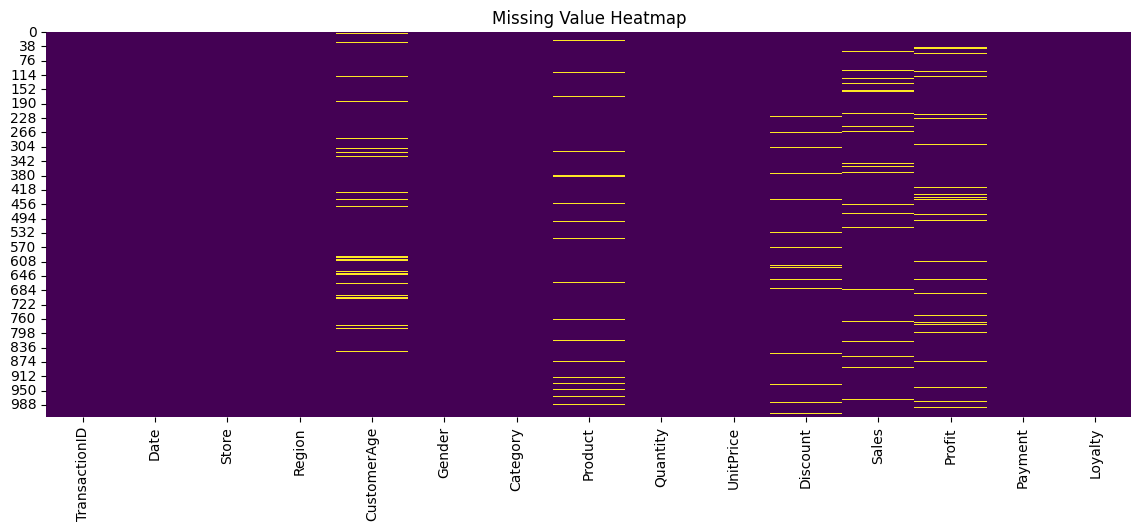

In [44]:
plt.figure(figsize=(14,5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [45]:
duplicate_count = df.duplicated().sum()
print("\nDuplicate Rows :", duplicate_count)
print("\nDuplicate Records")
display(df[df.duplicated()])


Duplicate Rows : 20

Duplicate Records


,TransactionID,Date,Store,Region,CustomerAge,Gender,Category,Product,Quantity,UnitPrice,Discount,Sales,Profit,Payment,Loyalty
1000,100099,2025-01-22,S2,North,60.0,M,Home,Product_17,1,489.24,0.20,391.39,65.76,Cash,Yes
1001,100844,2025-04-26,S4,East,39.0,M,Electronics,Product_48,10,188.22,0.00,1882.20,473.69,Card,Yes
1002,100119,2025-02-19,S1,East,69.0,F,Clothing,Product_42,5,489.71,0.10,2203.69,226.68,Cash,Yes
1003,100480,2025-04-30,S3,South,45.0,F,Electronics,Product_95,3,65.41,0.15,166.80,40.49,Cash,No
1004,100156,2025-12-08,S3,North,60.0,M,Electronics,Product_43,6,399.13,0.05,2275.04,486.56,UPI,Yes
1005,100730,2025-05-14,S1,West,23.0,F,Electronics,Product_10,4,169.49,0.10,610.16,68.13,UPI,No
1006,100136,2025-05-30,S1,East,27.0,M,Home,Product_15,9,125.45,0.00,NaN,323.14,UPI,No
1007,100737,2025-11-05,S2,West,21.0,M,Grocery,NaN,1,104.17,0.05,98.96,23.11,Card,Yes
1008,100903,2025-02-08,S2,West,21.0,F,Home,Product_72,5,162.61,0.10,731.75,129.02,Card,No
1009,100868,2025-06-19,S2,South,42.0,M,Grocery,Product_17,2,165.61,0.05,314.66,64.24,Cash,No


In [46]:
summary = pd.DataFrame({
    "Metric":["Rows", "Columns", "Missing Values", "Duplicate Rows", "Numerical Columns", "Categorical Columns"],
    "Value":[df.shape[0], df.shape[1], df.isnull().sum().sum(), duplicate_count, len(df.select_dtypes(include='number').columns),
             len(df.select_dtypes(include='object').columns)
]})
print("\nOverall Dataset Summary")
display(summary)


Overall Dataset Summary


,Metric,Value
0,Rows,1020
1,Columns,15
2,Missing Values,256
3,Duplicate Rows,20
4,Numerical Columns,7
5,Categorical Columns,8


In [47]:
df_clean = df.copy()

print("\nMissing Values Before Cleaning")
display(df_clean.isnull().sum())

print("\nMissing Value Percentage")
missing_percentage = pd.DataFrame({"Missing Values":df_clean.isnull().sum(), "Percentage":round(df_clean.isnull().mean()*100,2)})
display(missing_percentage)


Missing Values Before Cleaning


,0
TransactionID,0
Date,0
Store,0
Region,0
CustomerAge,50
Gender,0
Category,0
Product,51
Quantity,0
UnitPrice,0



Missing Value Percentage


,Missing Values,Percentage
TransactionID,0,0.0
Date,0,0.0
Store,0,0.0
Region,0,0.0
CustomerAge,50,4.9
Gender,0,0.0
Category,0,0.0
Product,51,5.0
Quantity,0,0.0
UnitPrice,0,0.0


In [48]:
numerical_columns = df_clean.select_dtypes(include=['int64','float64']).columns #number
categorical_columns = df_clean.select_dtypes(include=['object']).columns

print("\nNumerical Columns")
print(list(numerical_columns))
print("\nCategorical Columns")
print(list(categorical_columns))


Numerical Columns
['TransactionID', 'CustomerAge', 'Quantity', 'UnitPrice', 'Discount', 'Sales', 'Profit']

Categorical Columns
['Date', 'Store', 'Region', 'Gender', 'Category', 'Product', 'Payment', 'Loyalty']


In [49]:
df_mean = df_clean.copy()

for column in numerical_columns:
    df_mean[column].fillna(df_mean[column].mean(), inplace=True)

print("\nMissing Values after Mean Imputation")
display(df_mean.isnull().sum())


Missing Values after Mean Imputation


,0
TransactionID,0
Date,0
Store,0
Region,0
CustomerAge,0
Gender,0
Category,0
Product,51
Quantity,0
UnitPrice,0


In [50]:
df_median = df_clean.copy()

for column in numerical_columns:
    df_median[column].fillna(df_median[column].median(), inplace=True)

print("\nMissing Values after Median Imputation")
display(df_median.isnull().sum())


Missing Values after Median Imputation


,0
TransactionID,0
Date,0
Store,0
Region,0
CustomerAge,0
Gender,0
Category,0
Product,51
Quantity,0
UnitPrice,0


In [51]:
df_clean = df_median.copy()

In [52]:
for column in categorical_columns:
    df_clean[column].fillna(df_clean[column].mode()[0], inplace=True)

print("\nMissing Values after Mode Imputation")
display(df_clean.isnull().sum())


Missing Values after Mode Imputation


,0
TransactionID,0
Date,0
Store,0
Region,0
CustomerAge,0
Gender,0
Category,0
Product,0
Quantity,0
UnitPrice,0


In [53]:
print("\nTotal Missing Values Remaining :", df_clean.isnull().sum().sum())


Total Missing Values Remaining : 0


In [54]:
duplicate_rows = df_clean.duplicated().sum()
print("\nDuplicate Rows Before Removing :", duplicate_rows)
print("\nDuplicate Records")
display(df_clean[df_clean.duplicated()])


Duplicate Rows Before Removing : 20

Duplicate Records


,TransactionID,Date,Store,Region,CustomerAge,Gender,Category,Product,Quantity,UnitPrice,Discount,Sales,Profit,Payment,Loyalty
1000,100099,2025-01-22,S2,North,60.0,M,Home,Product_17,1,489.24,0.20,391.390,65.76,Cash,Yes
1001,100844,2025-04-26,S4,East,39.0,M,Electronics,Product_48,10,188.22,0.00,1882.200,473.69,Card,Yes
1002,100119,2025-02-19,S1,East,69.0,F,Clothing,Product_42,5,489.71,0.10,2203.690,226.68,Cash,Yes
1003,100480,2025-04-30,S3,South,45.0,F,Electronics,Product_95,3,65.41,0.15,166.800,40.49,Cash,No
1004,100156,2025-12-08,S3,North,60.0,M,Electronics,Product_43,6,399.13,0.05,2275.040,486.56,UPI,Yes
1005,100730,2025-05-14,S1,West,23.0,F,Electronics,Product_10,4,169.49,0.10,610.160,68.13,UPI,No
1006,100136,2025-05-30,S1,East,27.0,M,Home,Product_15,9,125.45,0.00,945.435,323.14,UPI,No
1007,100737,2025-11-05,S2,West,21.0,M,Grocery,Product_25,1,104.17,0.05,98.960,23.11,Card,Yes
1008,100903,2025-02-08,S2,West,21.0,F,Home,Product_72,5,162.61,0.10,731.750,129.02,Card,No
1009,100868,2025-06-19,S2,South,42.0,M,Grocery,Product_17,2,165.61,0.05,314.660,64.24,Cash,No


In [55]:
df_clean.drop_duplicates(inplace=True)
print("\nDuplicate Rows After Removing :", df_clean.duplicated().sum())


Duplicate Rows After Removing : 0


In [56]:
print("\nDataset Shape Before Cleaning :", df.shape)
print("Dataset Shape After Cleaning :", df_clean.shape)


Dataset Shape Before Cleaning : (1020, 15)
Dataset Shape After Cleaning : (1000, 15)


In [57]:
print("\nData Types")
display(df_clean.dtypes)


Data Types


,0
TransactionID,int64
Date,object
Store,object
Region,object
CustomerAge,float64
Gender,object
Category,object
Product,object
Quantity,int64
UnitPrice,float64


In [58]:
print("\nFinal Missing Values")
display(df_clean.isnull().sum())


Final Missing Values


,0
TransactionID,0
Date,0
Store,0
Region,0
CustomerAge,0
Gender,0
Category,0
Product,0
Quantity,0
UnitPrice,0


In [59]:
summary = pd.DataFrame({"Description":["Rows", "Columns", "Missing Values", "Duplicate Rows", "Numerical Columns", "Categorical Columns"],
    "Value":[df_clean.shape[0], df_clean.shape[1], df_clean.isnull().sum().sum(), df_clean.duplicated().sum(), len(numerical_columns),
        len(categorical_columns)]})

print("\nFinal Dataset Summary")
display(summary)


Final Dataset Summary


,Description,Value
0,Rows,1000
1,Columns,15
2,Missing Values,0
3,Duplicate Rows,0
4,Numerical Columns,7
5,Categorical Columns,8


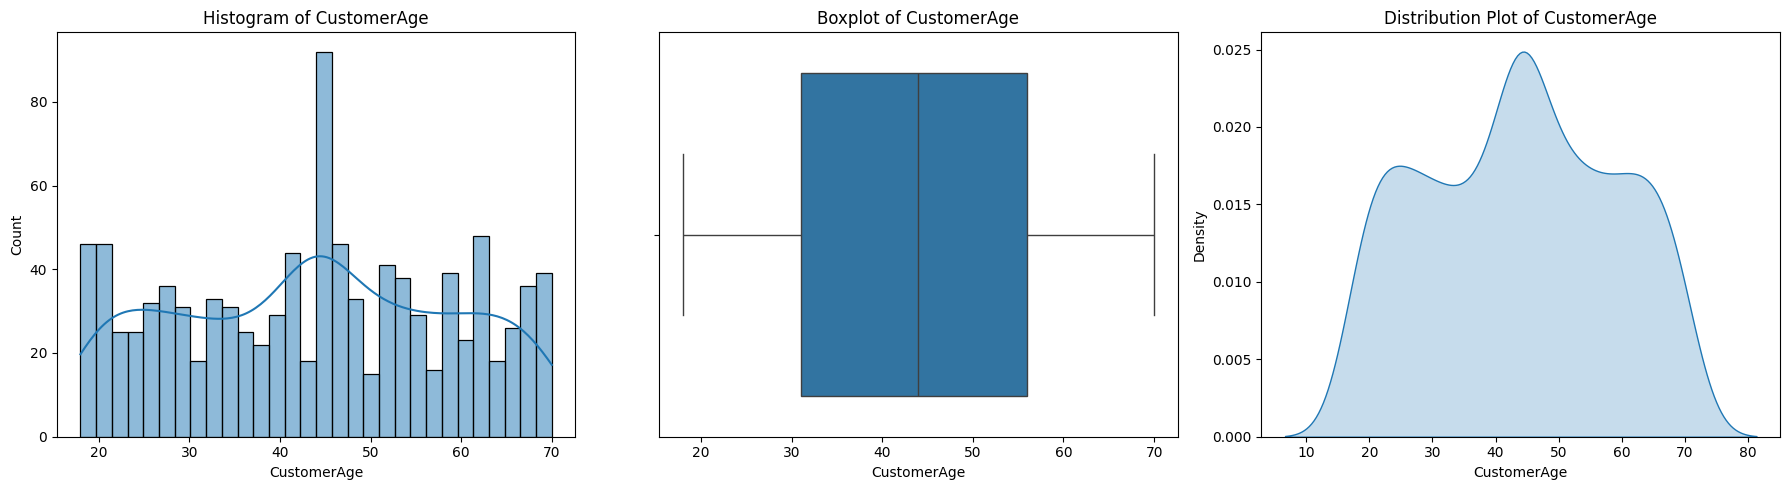

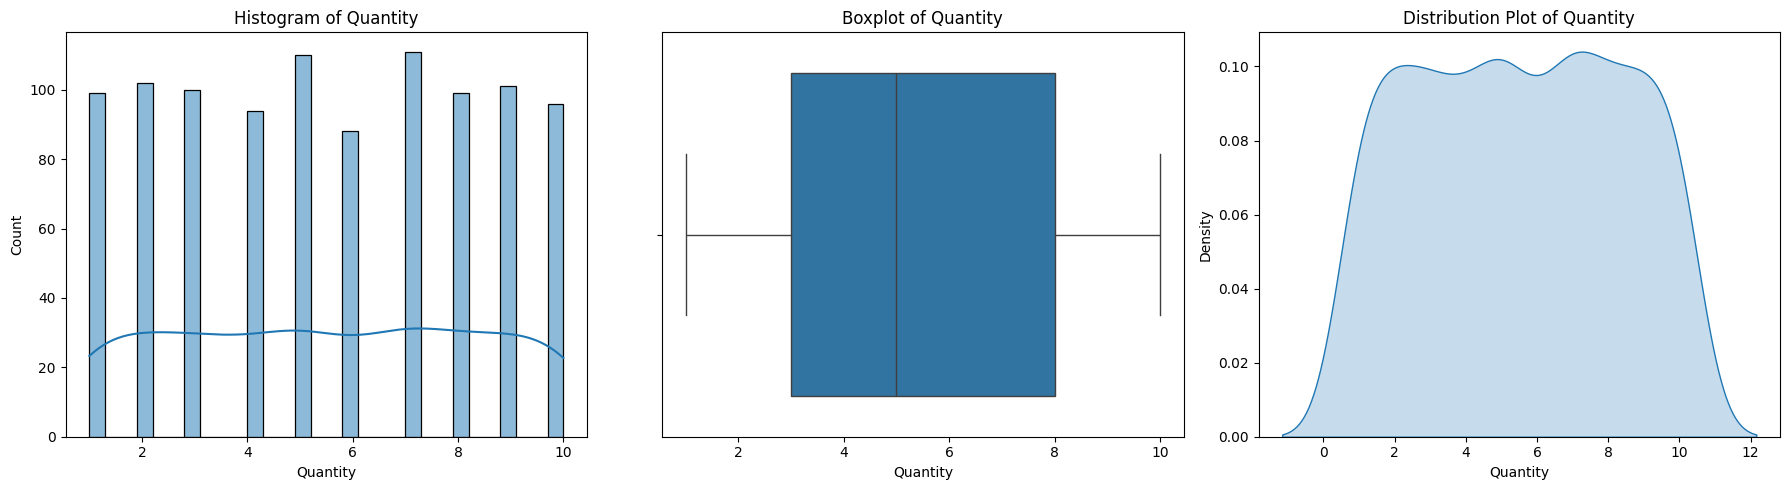

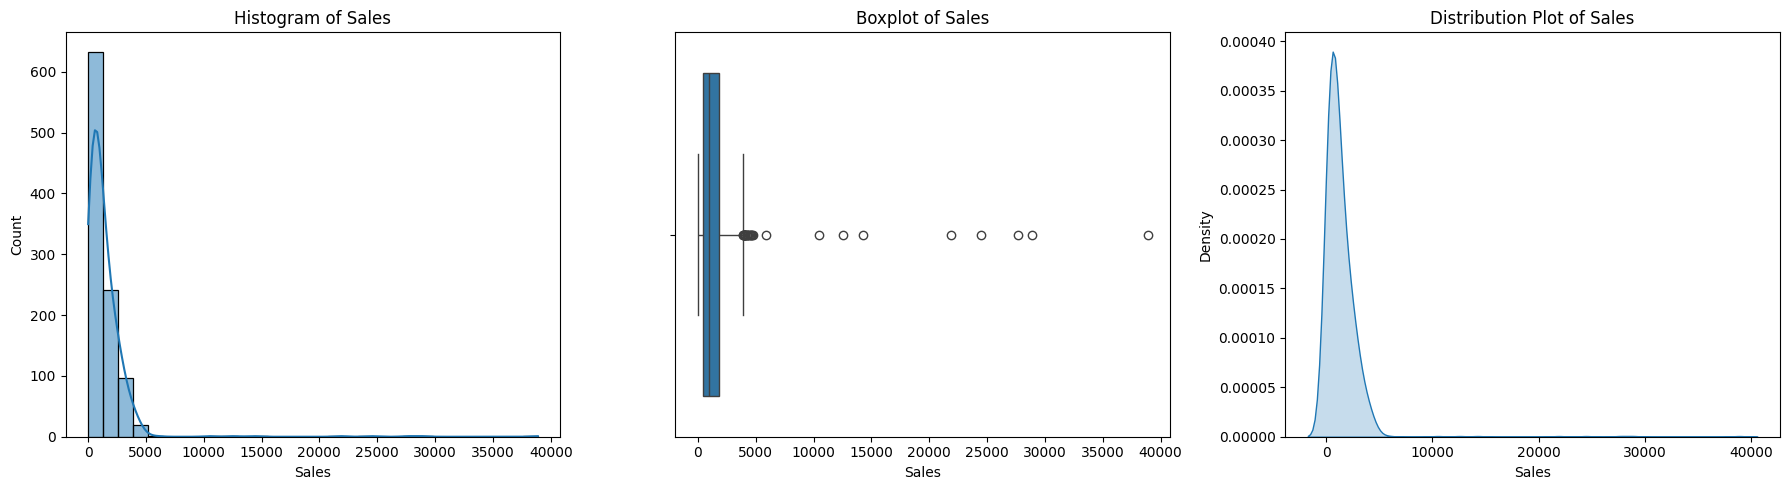

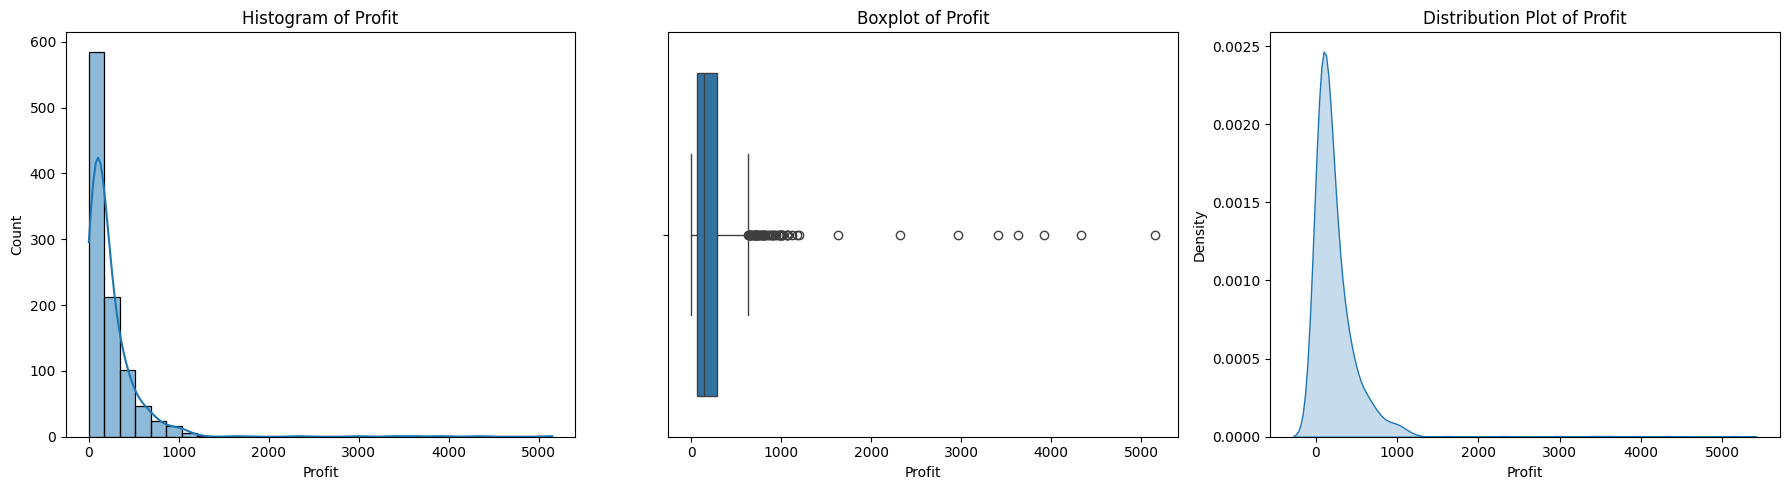

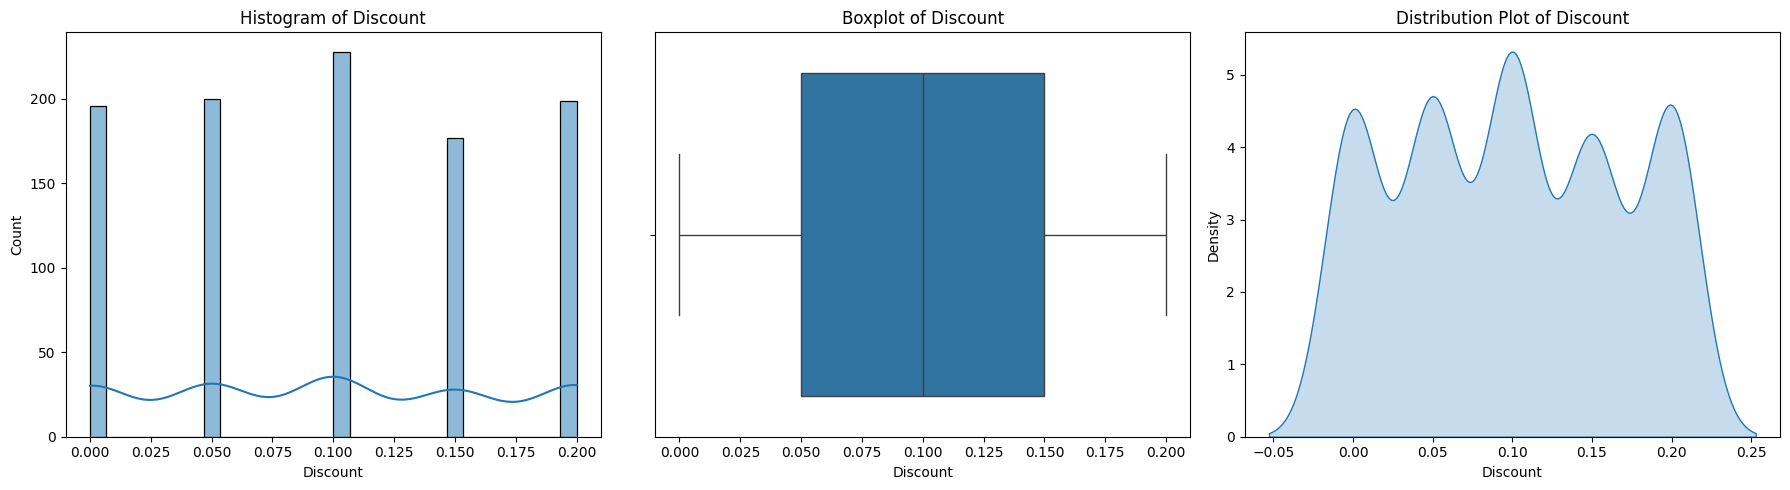

In [60]:
numerical_features = ['CustomerAge','Quantity','Sales','Profit','Discount']

for column in numerical_features:
    plt.figure(figsize=(18,5))
    plt.subplot(1,3,1)
    sns.histplot(df_clean[column], bins=30, kde=True)
    plt.title(f'Histogram of {column}')

    plt.subplot(1,3,2)
    sns.boxplot(x=df_clean[column])
    plt.title(f'Boxplot of {column}')

    plt.subplot(1,3,3)
    sns.kdeplot(df_clean[column], fill=True)
    plt.title(f'Distribution Plot of {column}')

    plt.tight_layout()
    plt.show()

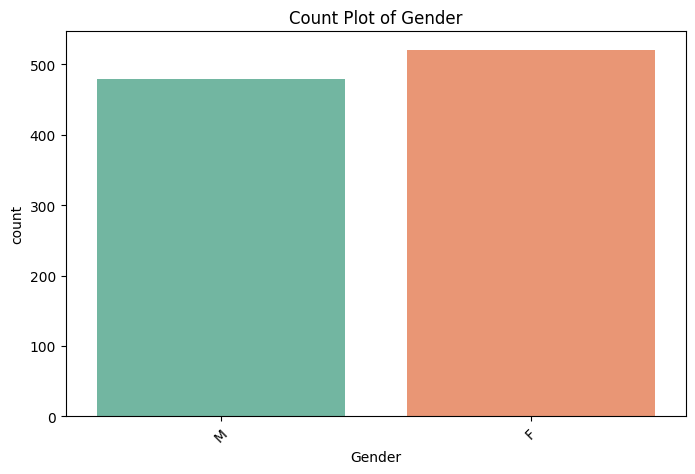

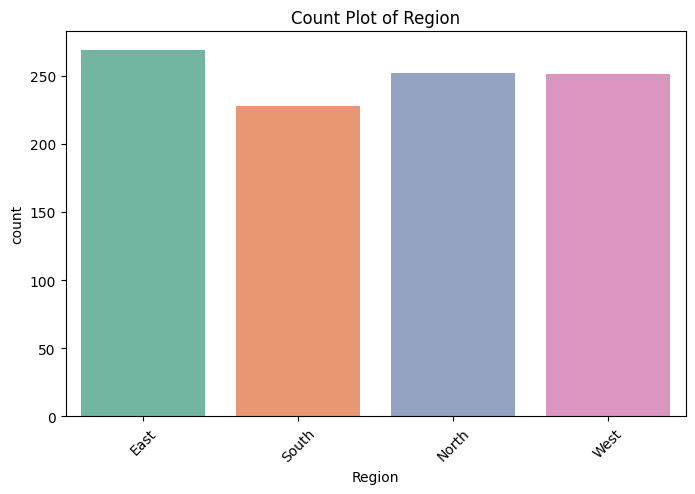

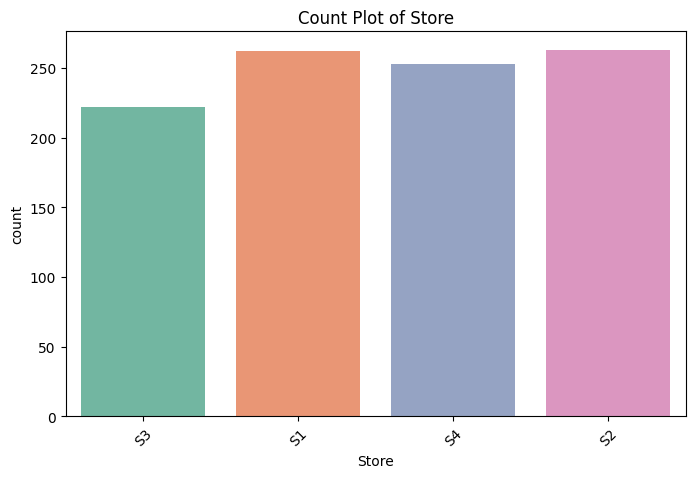

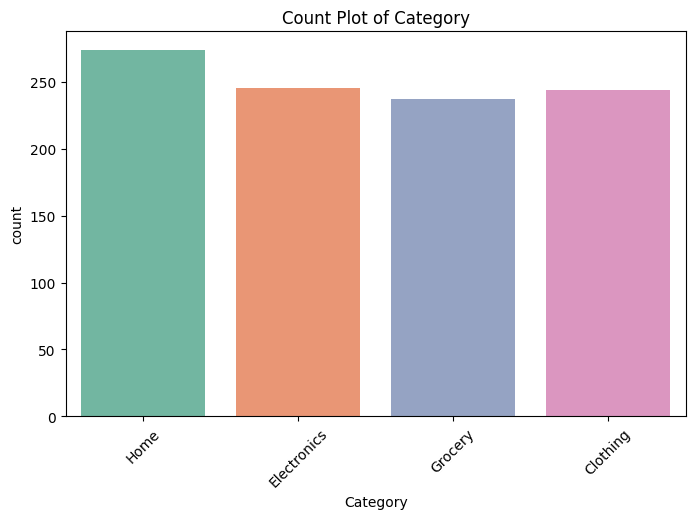

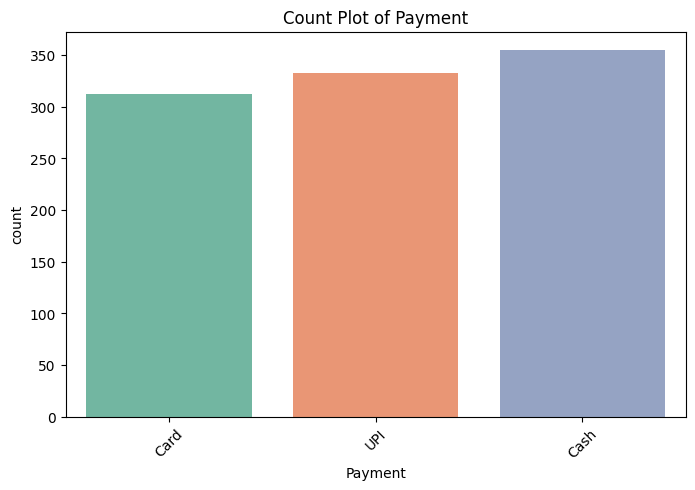

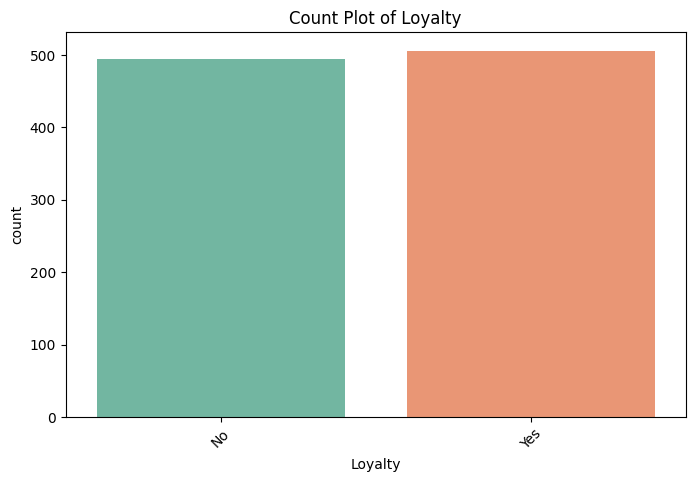

In [61]:
categorical_features = ['Gender','Region','Store', 'Category','Payment','Loyalty']

for column in categorical_features:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df_clean, x=column, palette='Set2')
    plt.title(f'Count Plot of {column}')
    plt.xticks(rotation=45)
    plt.show()

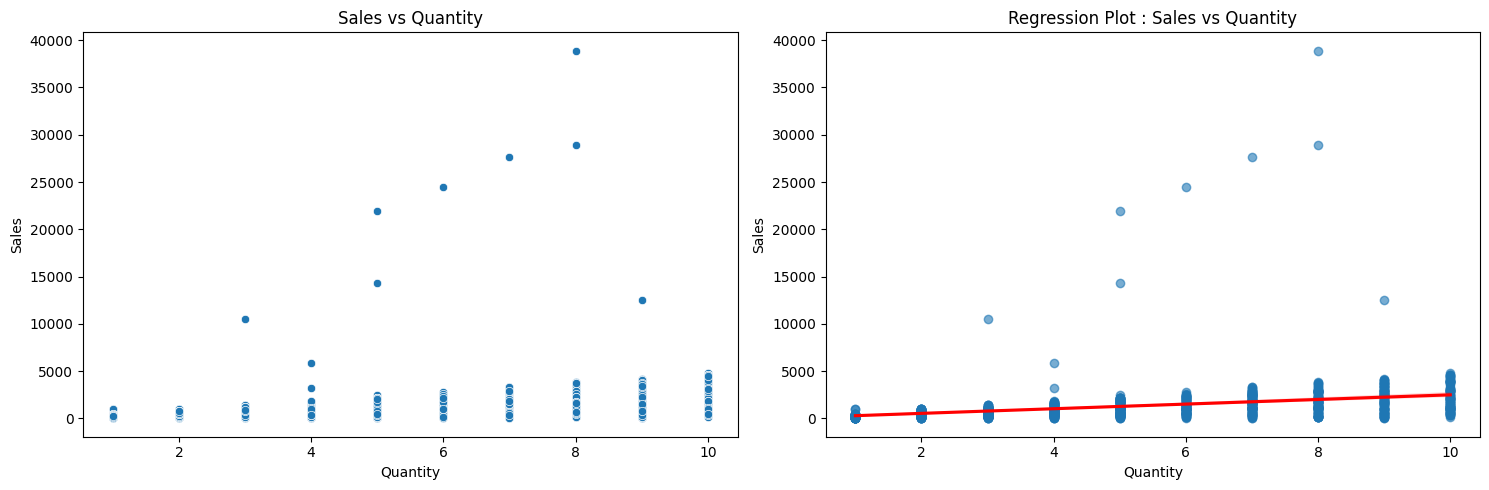

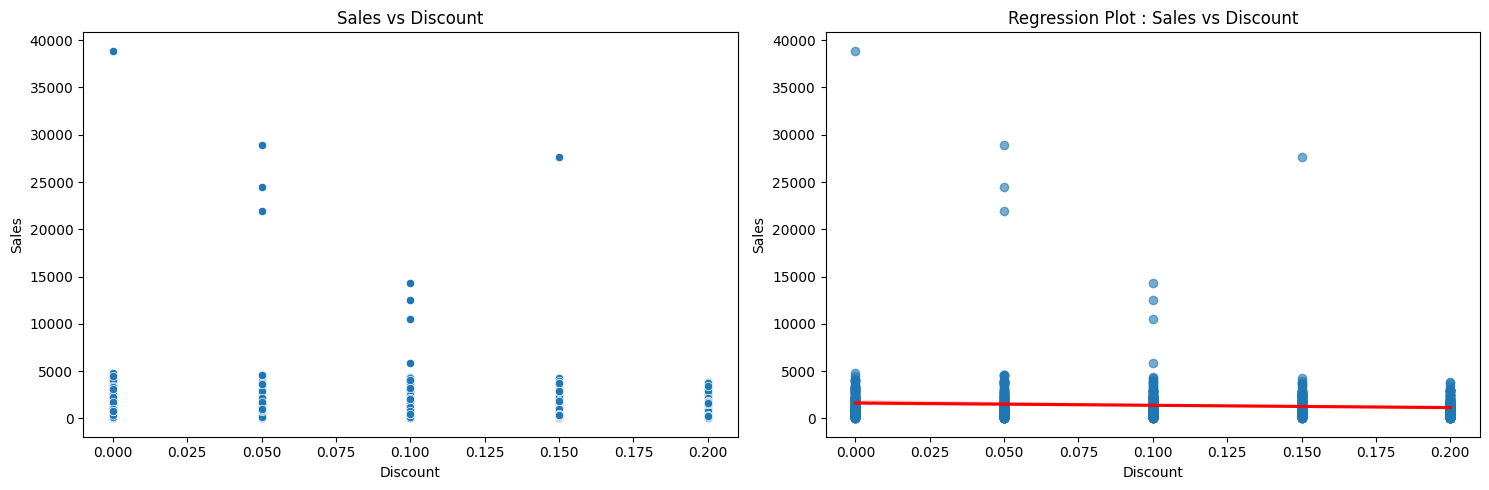

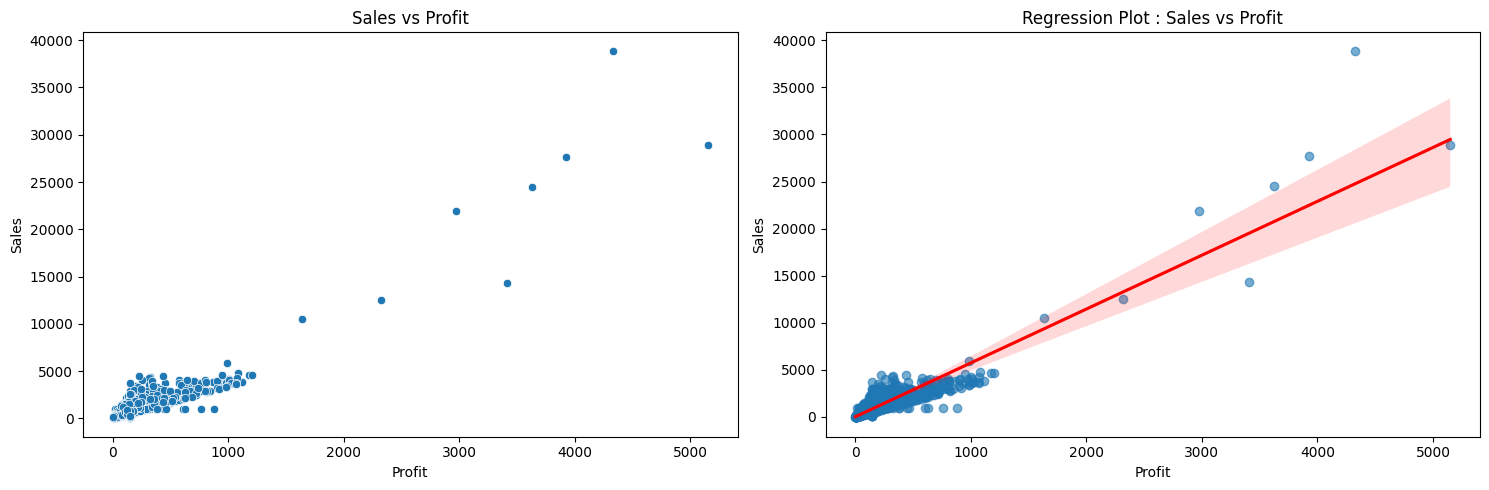

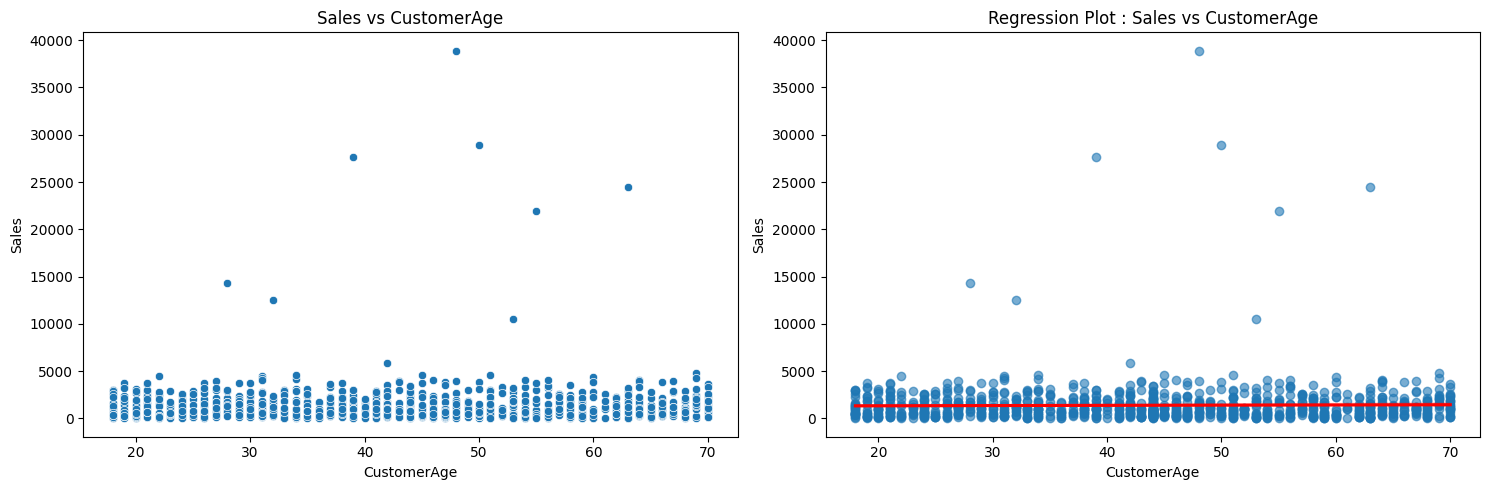

In [62]:
pairs = [('Quantity','Sales'), ('Discount','Sales'), ('Profit','Sales'), ('CustomerAge','Sales')]

for x,y in pairs:
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    sns.scatterplot(data=df_clean, x=x, y=y)
    plt.title(f'{y} vs {x}')

    plt.subplot(1,2,2)
    sns.regplot(data=df_clean, x=x, y=y, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'Regression Plot : {y} vs {x}')
    plt.tight_layout()
    plt.show()

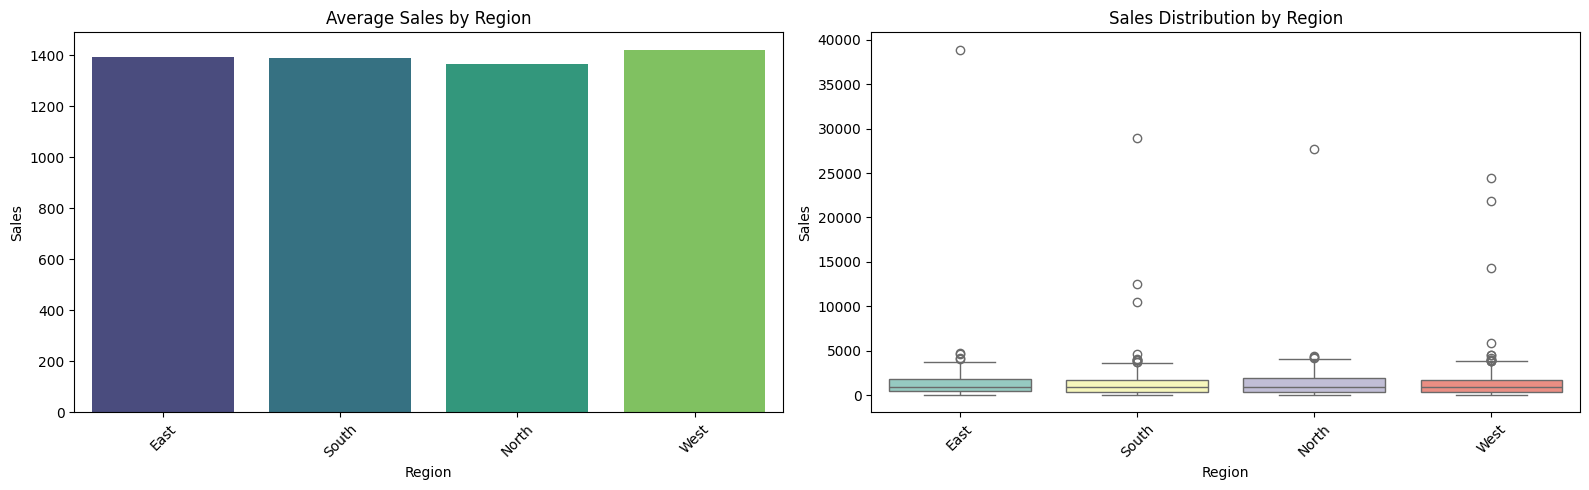

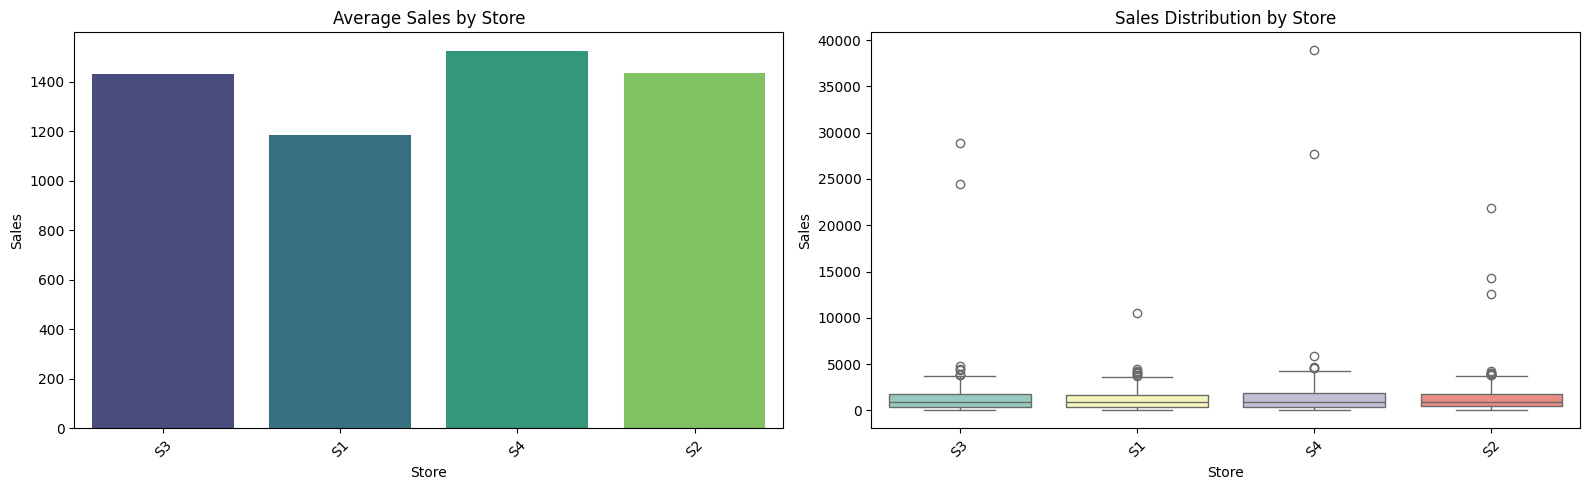

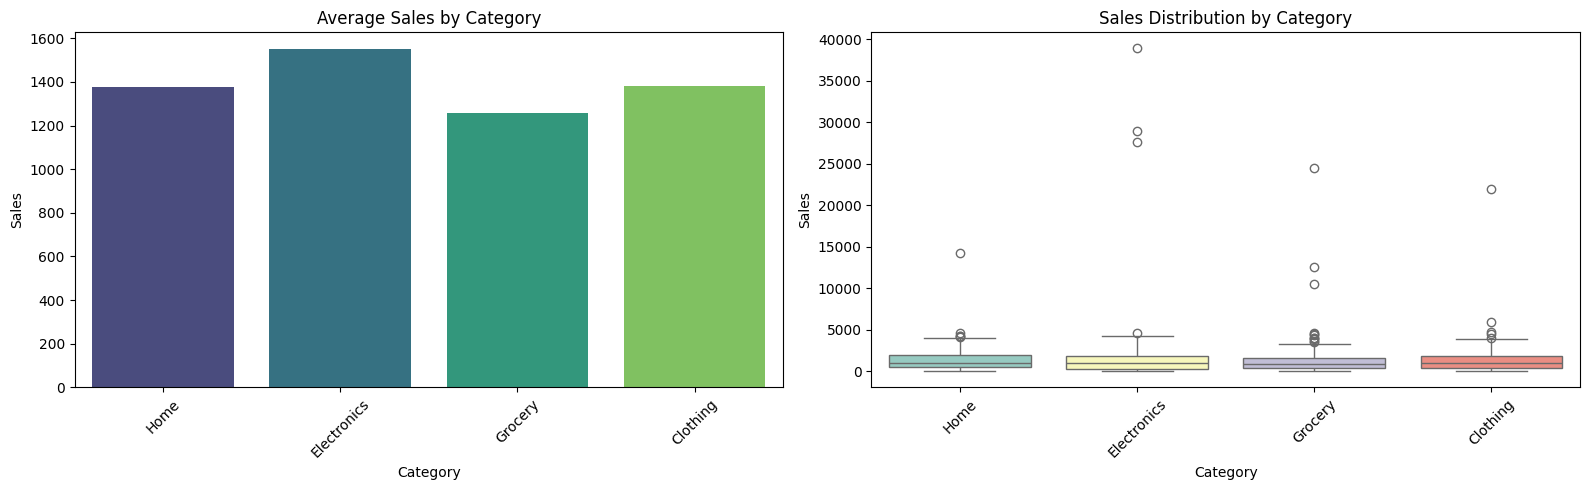

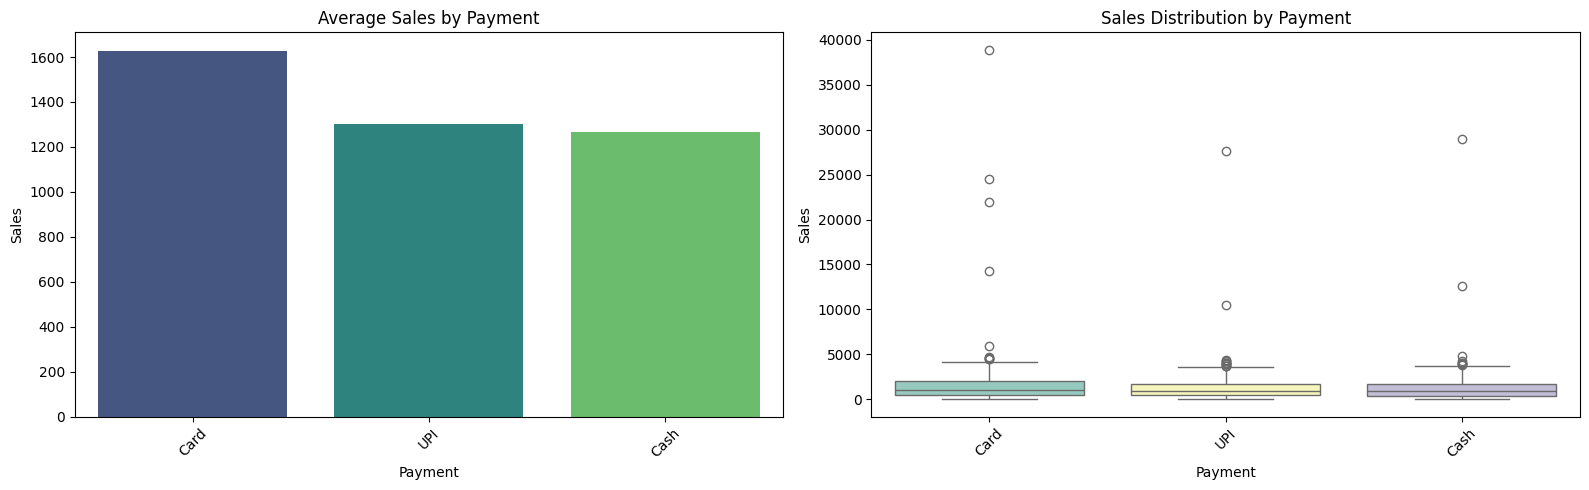

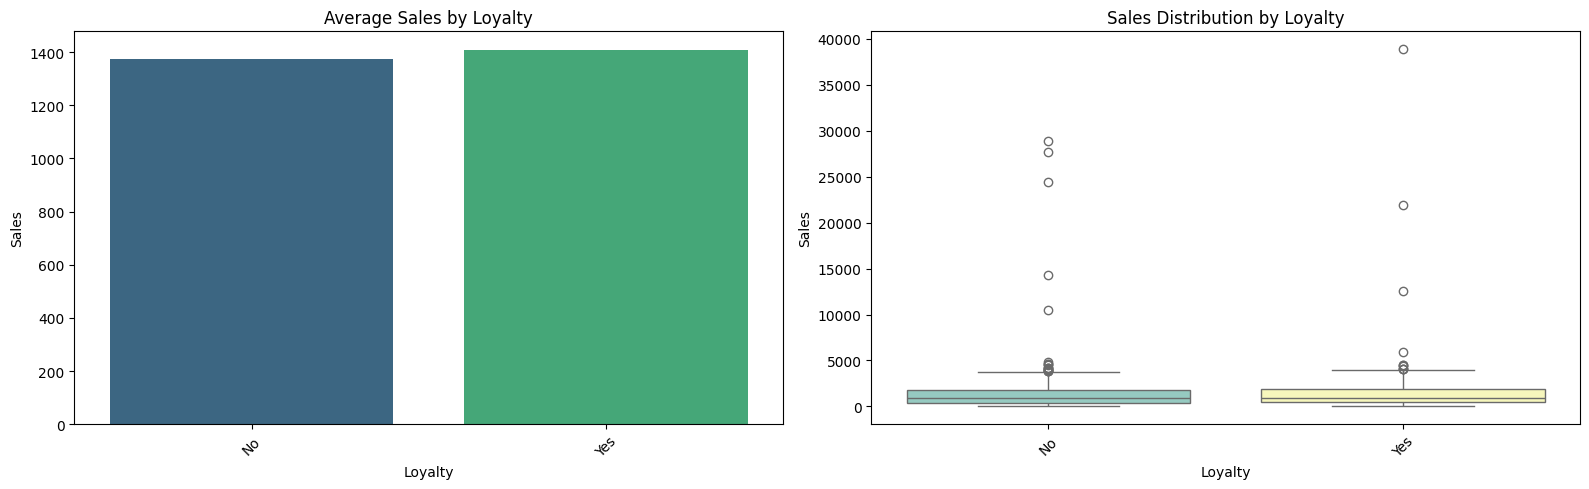

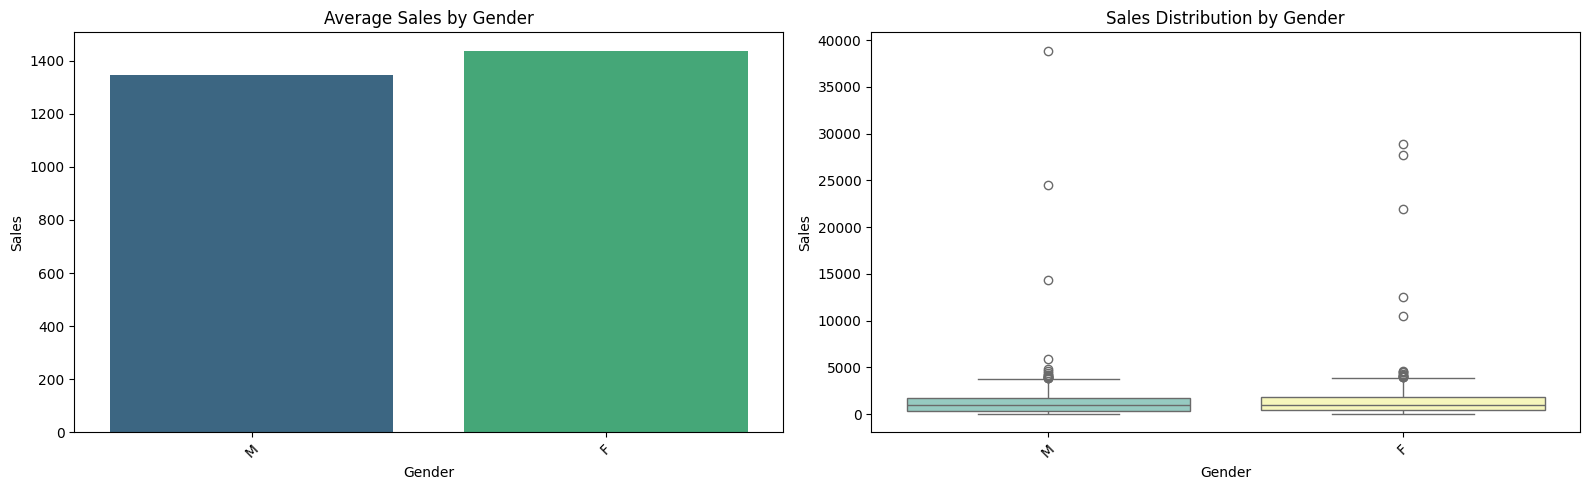

In [63]:
sales_categories = ['Region', 'Store', 'Category', 'Payment', 'Loyalty', 'Gender']

for column in sales_categories:
    plt.figure(figsize=(16,5))
    plt.subplot(1,2,1)
    sns.barplot(data=df_clean, x=column, y='Sales', estimator='mean', errorbar=None, palette='viridis')
    plt.title(f'Average Sales by {column}')
    plt.xticks(rotation=45)

    plt.subplot(1,2,2)
    sns.boxplot(data=df_clean, x=column, y='Sales', palette='Set3')
    plt.title(f'Sales Distribution by {column}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

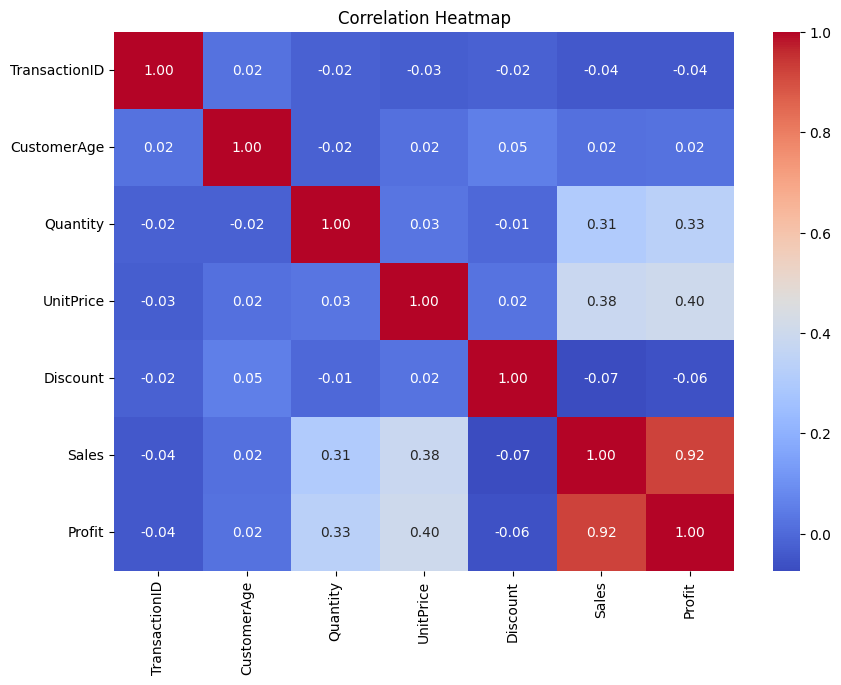

In [64]:
plt.figure(figsize=(10,7))
sns.heatmap(df_clean.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

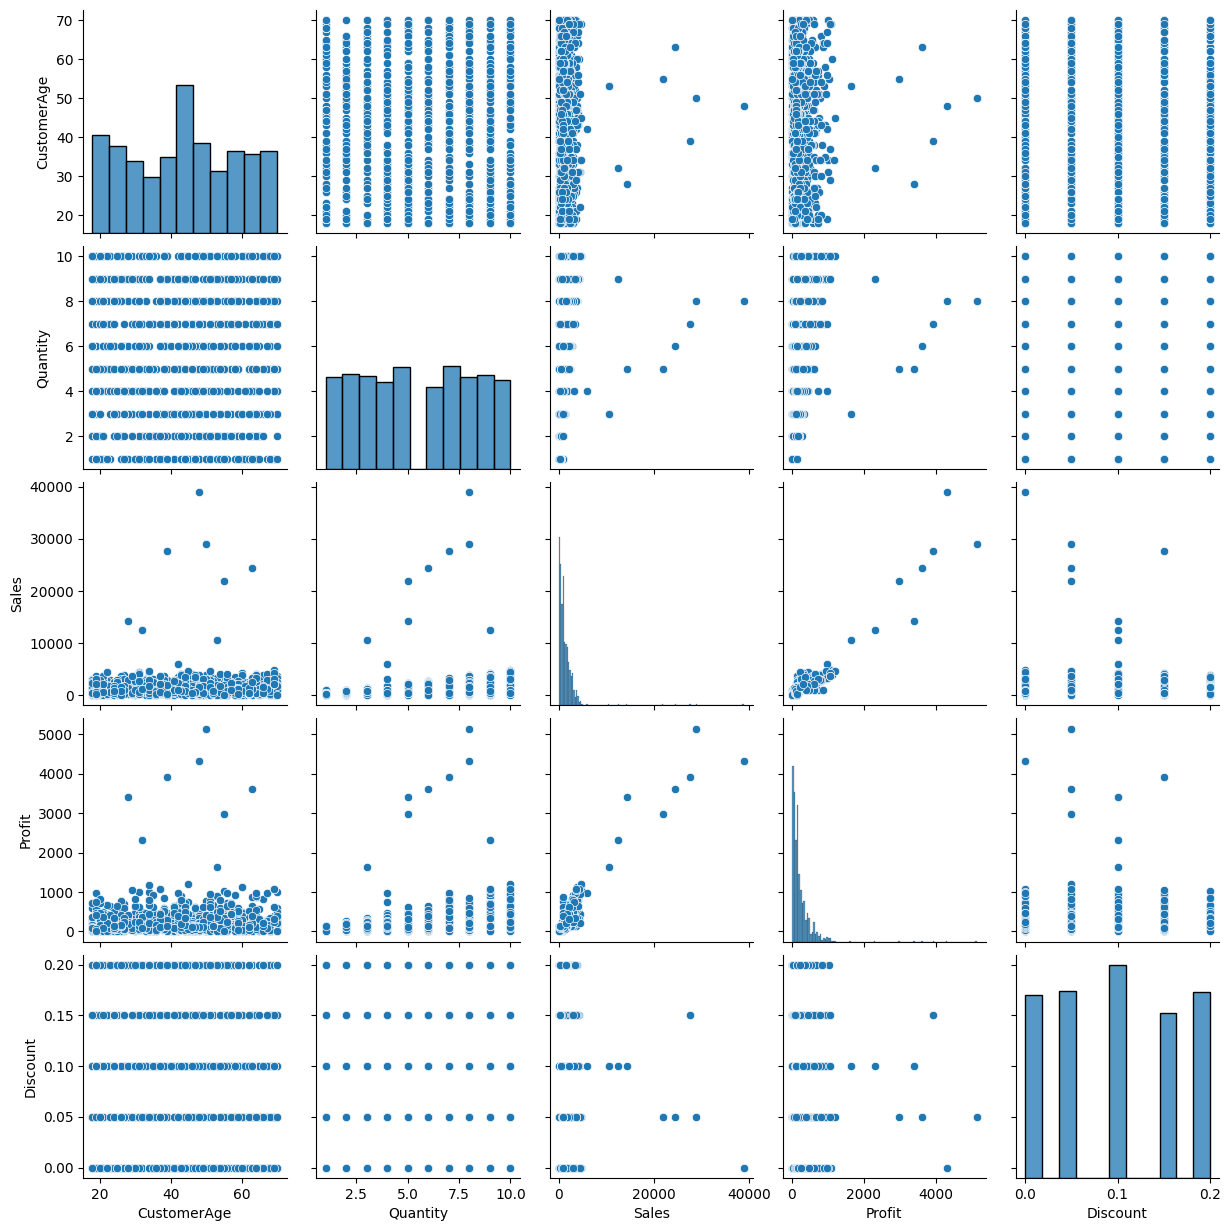

In [65]:
sns.pairplot(df_clean[['CustomerAge', 'Quantity', 'Sales', 'Profit', 'Discount']])
plt.show()

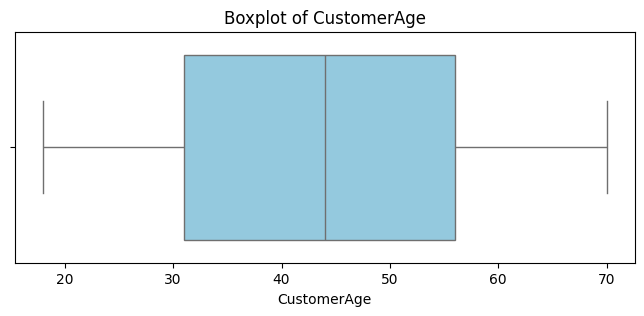

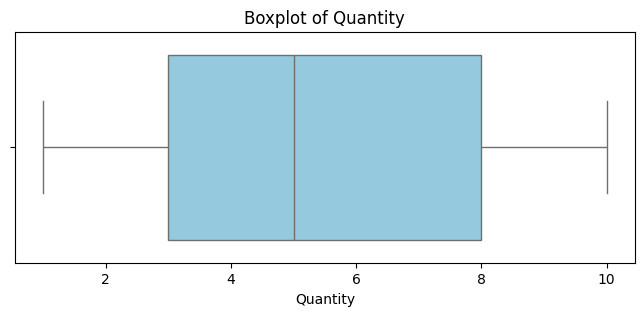

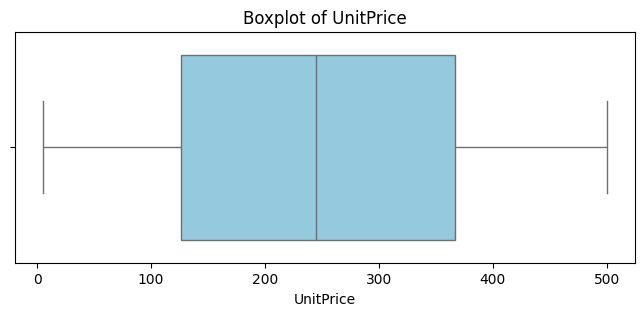

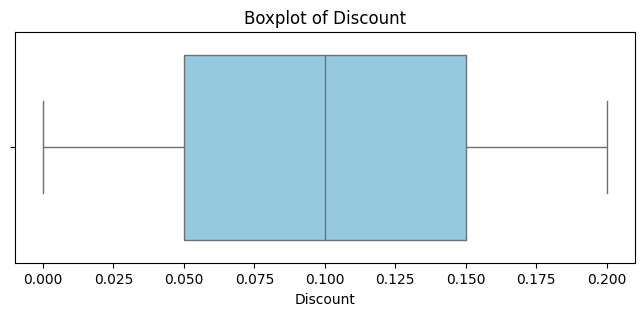

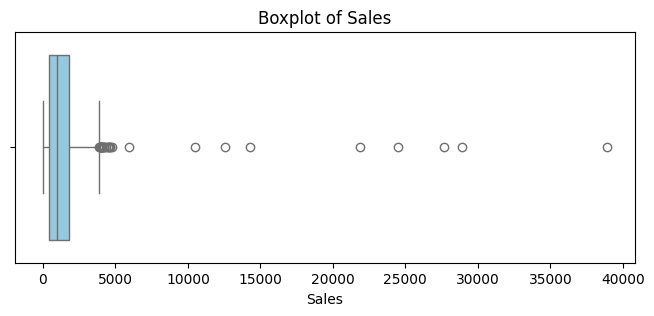

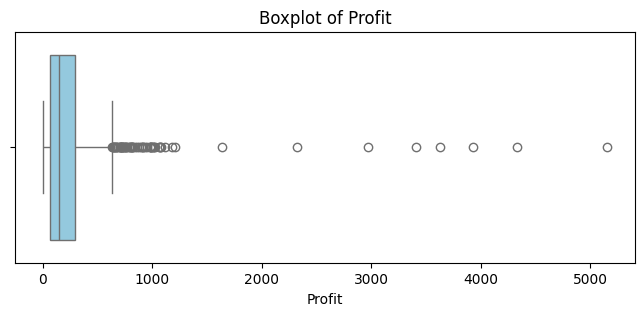

,Column,Outlier Count,Lower Limit,Upper Limit
0,CustomerAge,0,-6.50000,93.50000
1,Quantity,0,-4.50000,15.50000
2,UnitPrice,0,-234.45125,727.93875
3,Discount,0,-0.10000,0.30000
4,Sales,30,-1673.18000,3890.92000
5,Profit,66,-278.31875,635.05125


In [66]:
numerical_columns = ['CustomerAge', 'Quantity', 'UnitPrice', 'Discount', 'Sales', 'Profit']

for col in numerical_columns:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df_clean[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

outlier_summary = []
for col in numerical_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    outlier_summary.append([col, len(outliers), lower, upper])

summary = pd.DataFrame(outlier_summary, columns=['Column', 'Outlier Count', 'Lower Limit', 'Upper Limit'])
display(summary)

In [71]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df_clean[numerical_columns]))
z_outliers = (z_scores > 3).sum(axis=0)
z_summary = pd.DataFrame({"Column": numerical_columns, "Outliers (|Z| > 3)": z_outliers})
df_removed = df_clean.copy()

for col in numerical_columns:
    Q1 = df_removed[col].quantile(0.25)
    Q3 = df_removed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_removed = df_removed[(df_removed[col] >= lower) & (df_removed[col] <= upper)]
display(z_summary)

,Column,Outliers (|Z| > 3)
0,CustomerAge,0
1,Quantity,0
2,UnitPrice,0
3,Discount,0
4,Sales,8
5,Profit,8


In [72]:
print("Original Shape :", df_clean.shape)
print("New Shape :", df_removed.shape)

Original Shape : (1000, 15)
New Shape : (904, 15)


In [73]:
df_capped = df_clean.copy()

for col in numerical_columns:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_capped[col] = np.where(df_capped[col] < lower, lower, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper, upper, df_capped[col])


Boxplots After Capping


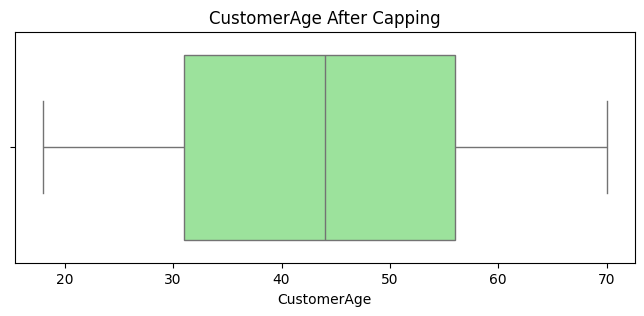

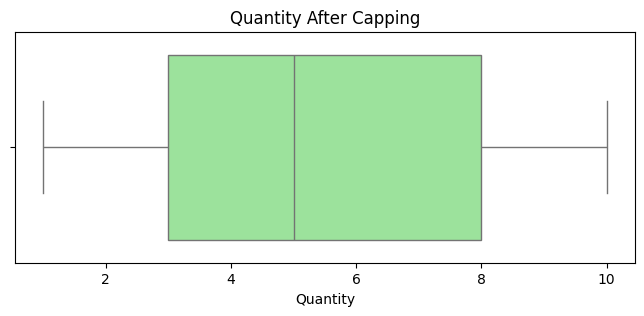

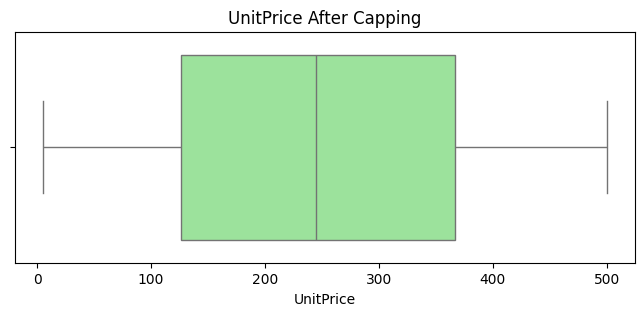

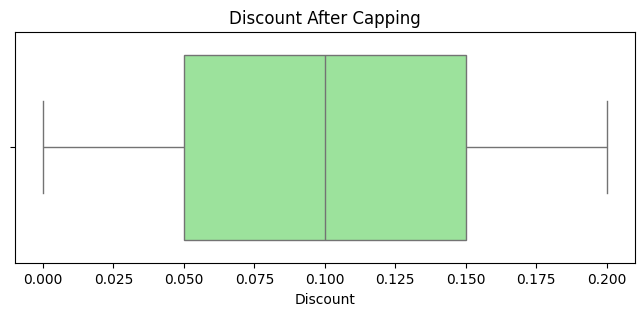

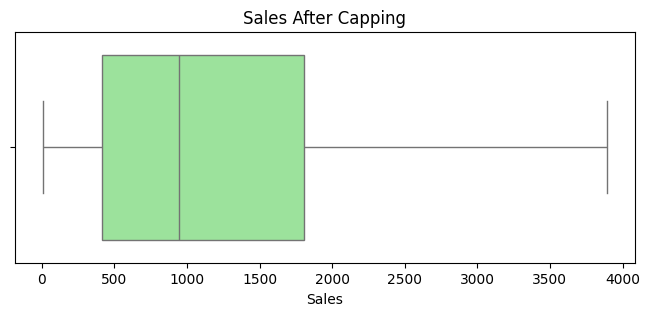

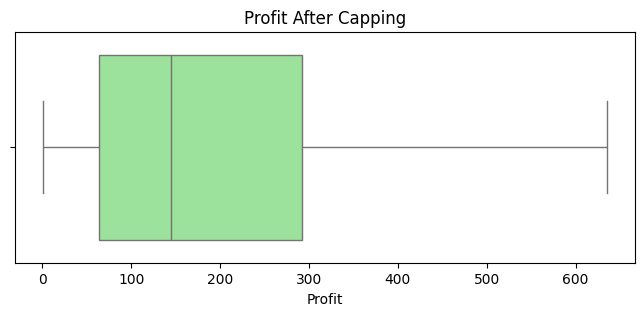

In [74]:
print("\nBoxplots After Capping")

for col in numerical_columns:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df_capped[col], color='lightgreen')
    plt.title(f'{col} After Capping')
    plt.show()

In [75]:
df_final = df_capped.copy()
print("\nFinal Dataset Shape :", df_final.shape)


Final Dataset Shape : (1000, 15)


In [76]:
df_feature = df_final.copy()

df_feature['Date'] = pd.to_datetime(df_feature['Date'])

In [77]:
df_feature['Year'] = df_feature['Date'].dt.year
df_feature['Month'] = df_feature['Date'].dt.month
df_feature['Month_Name'] = df_feature['Date'].dt.month_name()
df_feature['Day'] = df_feature['Date'].dt.day
df_feature['Weekday'] = df_feature['Date'].dt.day_name()
df_feature['Quarter'] = df_feature['Date'].dt.quarter
df_feature['WeekOfYear'] = df_feature['Date'].dt.isocalendar().week.astype(int)
df_feature['DayOfYear'] = df_feature['Date'].dt.dayofyear
df_feature['IsWeekend'] = np.where(df_feature['Date'].dt.weekday >= 5,1,0)

In [78]:
df_feature['Average_Item_Price'] = (df_feature['Sales'] / df_feature['Quantity'])

In [79]:
df_feature['Discount_Amount'] = (df_feature['UnitPrice'] * df_feature['Quantity'] * df_feature['Discount'])

In [80]:
df_feature['Profit_Margin'] = ((df_feature['Profit'] / df_feature['Sales']) * 100)

In [81]:
df_feature['Age_Group'] = pd.cut(df_feature['CustomerAge'], bins=[0,25,35,45,55,100],
    labels=['18-25','26-35','36-45','46-55','55+'])

In [82]:
df_feature['High_Discount'] = np.where(df_feature['Discount'] >= 0.15, 1, 0)

In [ ]:
new_features = ['Year', 'Month', 'Month_Name', 'Day', 'Weekday', 'Quarter', 'WeekOfYear', 'DayOfYear', 'IsWeekend',
                'Average_Item_Price', 'Discount_Amount', 'Profit_Margin', 'Age_Group', 'High_Discount', 'High_Sales']

print("\nNew Features Created")
display(df_feature[new_features].head())

In [84]:
print("\nDataset Shape Before Feature Engineering")
print(df_final.shape)

print("\nDataset Shape After Feature Engineering")
print(df_feature.shape)


Dataset Shape Before Feature Engineering
(1000, 15)

Dataset Shape After Feature Engineering
(1000, 29)


In [85]:
print("\nData Types")
display(df_feature.dtypes)


Data Types


,0
TransactionID,int64
Date,datetime64[ns]
Store,object
Region,object
CustomerAge,float64
Gender,object
Category,object
Product,object
Quantity,float64
UnitPrice,float64


In [86]:
print("\nMissing Values")
display(df_feature.isnull().sum())


Missing Values


,0
TransactionID,0
Date,0
Store,0
Region,0
CustomerAge,0
Gender,0
Category,0
Product,0
Quantity,0
UnitPrice,0


In [87]:
print("\nUpdated Column List")
display(df_feature.columns)


Updated Column List


Index(['TransactionID', 'Date', 'Store', 'Region', 'CustomerAge', 'Gender',
       'Category', 'Product', 'Quantity', 'UnitPrice', 'Discount', 'Sales',
       'Profit', 'Payment', 'Loyalty', 'Year', 'Month', 'Month_Name', 'Day',
       'Weekday', 'Quarter', 'WeekOfYear', 'DayOfYear', 'IsWeekend',
       'Average_Item_Price', 'Discount_Amount', 'Profit_Margin', 'Age_Group',
       'High_Discount'],
      dtype='object')

In [88]:
df_encoded = df_feature.copy()

In [89]:
print("\nData Types Before Encoding")
display(df_encoded.dtypes)


Data Types Before Encoding


,0
TransactionID,int64
Date,datetime64[ns]
Store,object
Region,object
CustomerAge,float64
Gender,object
Category,object
Product,object
Quantity,float64
UnitPrice,float64


In [90]:
print("\nApplying Label Encoding...")
label_encoder = LabelEncoder()
label_columns = ['Gender', 'Loyalty']

for col in label_columns:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])


Applying Label Encoding...


In [91]:
onehot_columns = ['Region', 'Store', 'Category', 'Product', 'Payment', 'Month_Name', 'Weekday', 'Age_Group']

df_encoded = pd.get_dummies(df_encoded, columns=onehot_columns, drop_first=True, dtype=int)

In [92]:
df_encoded.drop(columns=['Date'], inplace=True)

In [93]:
display(df_encoded.head())

,TransactionID,CustomerAge,Gender,Quantity,UnitPrice,Discount,Sales,Profit,Loyalty,Year,Month,Day,Quarter,WeekOfYear,DayOfYear,IsWeekend,Average_Item_Price,Discount_Amount,Profit_Margin,High_Discount,Region_North,Region_South,Region_West,Store_S2,Store_S3,Store_S4,Category_Electronics,Category_Grocery,Category_Home,Product_Product_10,Product_Product_100,Product_Product_11,Product_Product_12,Product_Product_13,Product_Product_14,Product_Product_15,Product_Product_16,Product_Product_17,Product_Product_18,Product_Product_19,...,Product_Product_84,Product_Product_85,Product_Product_86,Product_Product_87,Product_Product_88,Product_Product_89,Product_Product_9,Product_Product_90,Product_Product_91,Product_Product_92,Product_Product_93,Product_Product_94,Product_Product_95,Product_Product_96,Product_Product_97,Product_Product_98,Product_Product_99,Payment_Cash,Payment_UPI,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Age_Group_26-35,Age_Group_36-45,Age_Group_46-55,Age_Group_55+
0,100000,52.0,1,2.0,251.99,0.10,453.58,44.88,0,2025,12,31,4,1,365,0,226.790,50.398,9.894616,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
1,100001,50.0,1,2.0,5.17,0.15,8.79,2.36,0,2025,8,18,3,34,230,0,4.395,1.551,26.848692,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2,100002,18.0,1,10.0,146.36,0.15,1244.06,221.54,0,2025,10,9,4,41,282,0,124.406,219.540,17.807823,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
3,100003,62.0,0,6.0,72.33,0.00,433.98,112.60,0,2025,4,16,2,16,106,0,72.330,0.000,25.945896,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
4,100004,44.0,0,4.0,164.77,0.20,527.26,88.94,1,2025,1,3,1,1,3,0,131.815,131.816,16.868338,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [94]:
print(df_encoded.shape)

(1000, 151)


In [95]:
display(df_encoded.dtypes)

,0
TransactionID,int64
CustomerAge,float64
Gender,int64
Quantity,float64
UnitPrice,float64
...,...
Weekday_Wednesday,int64
Age_Group_26-35,int64
Age_Group_36-45,int64
Age_Group_46-55,int64


In [96]:
display(df_encoded.isnull().sum())

,0
TransactionID,0
CustomerAge,0
Gender,0
Quantity,0
UnitPrice,0
...,...
Weekday_Wednesday,0
Age_Group_26-35,0
Age_Group_36-45,0
Age_Group_46-55,0


In [97]:
display(df_encoded.select_dtypes(include='number').columns)

Index(['TransactionID', 'CustomerAge', 'Gender', 'Quantity', 'UnitPrice',
       'Discount', 'Sales', 'Profit', 'Loyalty', 'Year',
       ...
       'Weekday_Monday', 'Weekday_Saturday', 'Weekday_Sunday',
       'Weekday_Thursday', 'Weekday_Tuesday', 'Weekday_Wednesday',
       'Age_Group_26-35', 'Age_Group_36-45', 'Age_Group_46-55',
       'Age_Group_55+'],
      dtype='object', length=151)

In [98]:
display(df_encoded.select_dtypes(include='object').columns)

Index([], dtype='object')

In [99]:
display(df_encoded.columns)

Index(['TransactionID', 'CustomerAge', 'Gender', 'Quantity', 'UnitPrice',
       'Discount', 'Sales', 'Profit', 'Loyalty', 'Year',
       ...
       'Weekday_Monday', 'Weekday_Saturday', 'Weekday_Sunday',
       'Weekday_Thursday', 'Weekday_Tuesday', 'Weekday_Wednesday',
       'Age_Group_26-35', 'Age_Group_36-45', 'Age_Group_46-55',
       'Age_Group_55+'],
      dtype='object', length=151)

In [100]:
x = df_encoded.drop(columns=['Sales'])
y = df_encoded['Sales']

In [101]:
print("\nShape of x :", x.shape)
print("Shape of y :", y.shape)
print("\nTotal Features :", x.shape[1])


Shape of x : (1000, 150)
Shape of y : (1000,)

Total Features : 150


In [102]:
display(pd.DataFrame(x.columns, columns=['Features']))

,Features
0,TransactionID
1,CustomerAge
2,Gender
3,Quantity
4,UnitPrice
...,...
145,Weekday_Wednesday
146,Age_Group_26-35
147,Age_Group_36-45
148,Age_Group_46-55


In [103]:
display(x.dtypes)

,0
TransactionID,int64
CustomerAge,float64
Gender,int64
Quantity,float64
UnitPrice,float64
...,...
Weekday_Wednesday,int64
Age_Group_26-35,int64
Age_Group_36-45,int64
Age_Group_46-55,int64


In [104]:
display(x.isnull().sum())

,0
TransactionID,0
CustomerAge,0
Gender,0
Quantity,0
UnitPrice,0
...,...
Weekday_Wednesday,0
Age_Group_26-35,0
Age_Group_36-45,0
Age_Group_46-55,0


In [105]:
corr = df_encoded.corr(numeric_only=True)
sales_corr = corr['Sales'].sort_values(ascending=False)
print("\nCorrelation with Sales")
display(sales_corr)


Correlation with Sales


,Sales
Sales,1.000000
Profit,0.831906
Average_Item_Price,0.673884
UnitPrice,0.671190
Quantity,0.608351
...,...
High_Discount,-0.066887
Category_Grocery,-0.075023
Discount,-0.086293
Profit_Margin,-0.155750


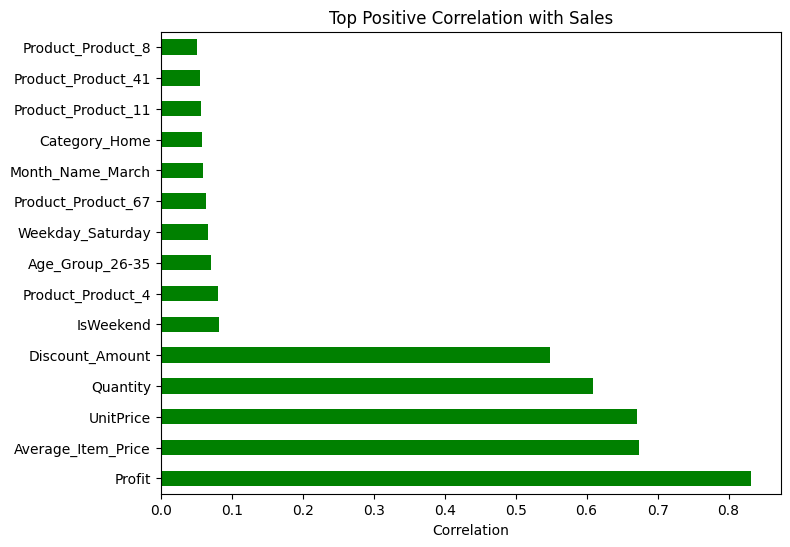

In [106]:
plt.figure(figsize=(8,6))
sales_corr[1:16].plot(kind='barh', color='green')
plt.title("Top Positive Correlation with Sales")
plt.xlabel("Correlation")
plt.show()

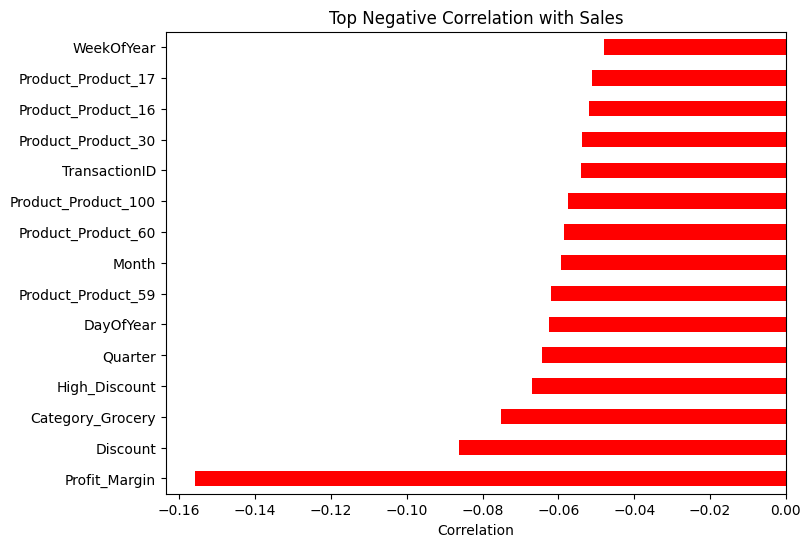

In [107]:
plt.figure(figsize=(8,6))
sales_corr.sort_values().head(15).plot(kind='barh', color='red')
plt.title("Top Negative Correlation with Sales")
plt.xlabel("Correlation")
plt.show()

In [108]:
high_corr = corr.abs()
high_corr_pairs = []

for i in range(len(high_corr.columns)):
    for j in range(i):
        if high_corr.iloc[i, j] > 0.80:
            high_corr_pairs.append([
                high_corr.columns[i],
                high_corr.columns[j],
                round(high_corr.iloc[i, j], 2)
            ])

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
display(high_corr_df)

,Feature 1,Feature 2,Correlation
0,Profit,Sales,0.83
1,Quarter,Month,0.97
2,WeekOfYear,Month,0.92
3,WeekOfYear,Quarter,0.90
4,DayOfYear,Month,1.00
5,DayOfYear,Quarter,0.97
6,DayOfYear,WeekOfYear,0.92
7,Average_Item_Price,UnitPrice,0.88
8,High_Discount,Discount,0.86


In [109]:
summary = pd.DataFrame({"Description":["Total Rows", "Total Features", "Target Variable", "Independent Variables", "Dependent Variable"],
    "Value":[x.shape[0], x.shape[1], "Sales", "x", "y"]})

print("\nFeature Selection Summary")
display(summary)


Feature Selection Summary


,Description,Value
0,Total Rows,1000
1,Total Features,150
2,Target Variable,Sales
3,Independent Variables,x
4,Dependent Variable,y


In [110]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [111]:
numerical_columns = x_train.select_dtypes(include=['int64','float64']).columns
print("\nNumerical Columns")
display(pd.DataFrame(numerical_columns,columns=['Numerical Features']))


Numerical Columns


,Numerical Features
0,TransactionID
1,CustomerAge
2,Gender
3,Quantity
4,UnitPrice
...,...
140,Weekday_Wednesday
141,Age_Group_26-35
142,Age_Group_36-45
143,Age_Group_46-55


In [112]:
scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_train_scaled[numerical_columns] = scaler.fit_transform(x_train[numerical_columns])

In [113]:
x_test_scaled = x_test.copy()
x_test_scaled[numerical_columns] = scaler.transform(x_test[numerical_columns])

In [114]:
print("\nTraining Dataset (Scaled)")
display(x_train_scaled.head())

print("\nTesting Dataset (Scaled)")
display(x_test_scaled.head())


Training Dataset (Scaled)


,TransactionID,CustomerAge,Gender,Quantity,UnitPrice,Discount,Profit,Loyalty,Year,Month,Day,Quarter,WeekOfYear,DayOfYear,IsWeekend,Average_Item_Price,Discount_Amount,Profit_Margin,High_Discount,Region_North,Region_South,Region_West,Store_S2,Store_S3,Store_S4,Category_Electronics,Category_Grocery,Category_Home,Product_Product_10,Product_Product_100,Product_Product_11,Product_Product_12,Product_Product_13,Product_Product_14,Product_Product_15,Product_Product_16,Product_Product_17,Product_Product_18,Product_Product_19,Product_Product_2,...,Product_Product_84,Product_Product_85,Product_Product_86,Product_Product_87,Product_Product_88,Product_Product_89,Product_Product_9,Product_Product_90,Product_Product_91,Product_Product_92,Product_Product_93,Product_Product_94,Product_Product_95,Product_Product_96,Product_Product_97,Product_Product_98,Product_Product_99,Payment_Cash,Payment_UPI,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Age_Group_26-35,Age_Group_36-45,Age_Group_46-55,Age_Group_55+
29,-1.618974,-0.122709,-0.960769,0.916405,-1.126290,0.750985,-0.125744,0.990050,2025,5,10,2,-0.456906,130,1.518481,-1.078860,-0.170031,0.829532,1.308382,-0.567727,-0.556174,1.732051,-0.586973,-0.540747,-0.590824,-0.573501,-0.548464,1.628793,-0.093953,-0.100504,-0.100504,-0.079305,-0.123404,-0.079305,-0.123404,-0.079305,-0.079305,-0.118075,-0.086929,-0.079305,...,-0.118075,-0.086929,-0.086929,-0.118075,-0.086929,-0.118075,-0.070888,-0.093953,-0.112509,-0.106668,-0.112509,-0.086929,-0.123404,-0.086929,-0.061352,-0.093953,-0.061352,-0.739857,1.416869,-0.279584,-0.31208,-0.307232,-0.304789,-0.302333,-0.342518,-0.289846,3.20431,-0.269047,-0.292373,-0.31208,-0.418023,2.270208,-0.403473,-0.397168,-0.415957,-0.399275,-0.438464,1.791794,-0.478413,-0.594675
535,0.129890,-0.722099,1.040833,0.916405,1.150516,0.027144,-0.316817,-1.010051,2025,9,12,3,0.750111,255,-0.658553,0.997580,1.177565,-0.969603,-0.764303,-0.567727,-0.556174,-0.577350,-0.586973,-0.540747,1.692553,-0.573501,1.823273,-0.613951,-0.093953,-0.100504,-0.100504,-0.079305,-0.123404,-0.079305,-0.123404,-0.079305,-0.079305,-0.118075,-0.086929,-0.079305,...,-0.118075,-0.086929,-0.086929,-0.118075,-0.086929,-0.118075,-0.070888,-0.093953,-0.112509,-0.106668,-0.112509,-0.086929,-0.123404,-0.086929,-0.061352,-0.093953,-0.061352,-0.739857,-0.705781,-0.279584,-0.31208,-0.307232,-0.304789,-0.302333,-0.342518,-0.289846,-0.31208,-0.269047,-0.292373,3.20431,-0.418023,-0.440488,-0.403473,-0.397168,-0.415957,-0.399275,2.280691,-0.558100,-0.478413,-0.594675
695,0.682891,1.009474,1.040833,1.270571,-1.254910,1.474826,-0.574065,0.990050,2025,3,9,1,-1.060415,68,1.518481,-1.212827,-0.046123,0.071600,1.308382,-0.567727,-0.556174,1.732051,-0.586973,-0.540747,1.692553,-0.573501,1.823273,-0.613951,-0.093953,-0.100504,-0.100504,-0.079305,-0.123404,-0.079305,-0.123404,-0.079305,-0.079305,-0.118075,-0.086929,-0.079305,...,-0.118075,-0.086929,-0.086929,-0.118075,-0.086929,-0.118075,-0.070888,-0.093953,-0.112509,-0.106668,-0.112509,-0.086929,-0.123404,-0.086929,-0.061352,-0.093953,-0.061352,1.351612,-0.705781,-0.279584,-0.31208,-0.307232,-0.304789,-0.302333,-0.342518,3.450105,-0.31208,-0.269047,-0.292373,-0.31208,-0.418023,-0.440488,2.478479,-0.397168,-0.415957,-0.399275,-0.438464,-0.558100,-0.478413,1.681592
557,0.205928,-0.588901,1.040833,0.562239,0.386665,1.474826,0.320935,-1.010051,2025,6,7,2,-0.188680,158,1.518481,0.097896,1.754621,-0.210862,1.308382,-0.567727,-0.556174,1.732051,1.703655,-0.540747,-0.590824,-0.573501,1.823273,-0.613951,-0.093953,-0.100504,-0.100504,-0.079305,-0.123404,-0.079305,-0.123404,-0.079305,-0.079305,-0.118075,-0.086929,-0.079305,...,-0.118075,-0.086929,-0.086929,-0.118075,-0.086929,-0.118075,-0.070888,-0.093953,-0.112509,-0.106668,-0.112509,-0.086929


Testing Dataset (Scaled)


,TransactionID,CustomerAge,Gender,Quantity,UnitPrice,Discount,Profit,Loyalty,Year,Month,Day,Quarter,WeekOfYear,DayOfYear,IsWeekend,Average_Item_Price,Discount_Amount,Profit_Margin,High_Discount,Region_North,Region_South,Region_West,Store_S2,Store_S3,Store_S4,Category_Electronics,Category_Grocery,Category_Home,Product_Product_10,Product_Product_100,Product_Product_11,Product_Product_12,Product_Product_13,Product_Product_14,Product_Product_15,Product_Product_16,Product_Product_17,Product_Product_18,Product_Product_19,Product_Product_2,...,Product_Product_84,Product_Product_85,Product_Product_86,Product_Product_87,Product_Product_88,Product_Product_89,Product_Product_9,Product_Product_90,Product_Product_91,Product_Product_92,Product_Product_93,Product_Product_94,Product_Product_95,Product_Product_96,Product_Product_97,Product_Product_98,Product_Product_99,Payment_Cash,Payment_UPI,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Age_Group_26-35,Age_Group_36-45,Age_Group_46-55,Age_Group_55+
521,0.081503,-1.321490,-0.960769,-0.500260,-0.739294,0.027144,-0.223636,-1.010051,2025,1,21,1,-1.462754,21,-0.658553,-0.649391,-0.467263,0.821759,-0.764303,1.761410,-0.556174,-0.577350,-0.586973,1.849294,-0.590824,-0.573501,-0.548464,-0.613951,-0.093953,-0.100504,-0.100504,-0.079305,-0.123404,-0.079305,-0.123404,-0.079305,-0.079305,-0.118075,-0.086929,-0.079305,...,-0.118075,-0.086929,-0.086929,-0.118075,-0.086929,-0.118075,-0.070888,-0.093953,-0.112509,-0.106668,-0.112509,-0.086929,-0.123404,-0.086929,-0.061352,-0.093953,-0.061352,-0.739857,1.416869,-0.279584,-0.31208,-0.307232,3.280961,-0.302333,-0.342518,-0.289846,-0.31208,-0.269047,-0.292373,-0.31208,-0.418023,-0.440488,-0.403473,-0.397168,2.404093,-0.399275,-0.438464,-0.558100,-0.478413,-0.594675
737,0.828054,-1.521287,1.040833,-1.562758,-1.014261,-0.696697,-0.984972,0.990050,2025,11,5,4,1.286563,309,-0.658553,-0.910115,-0.783398,0.355456,-0.764303,-0.567727,-0.556174,1.732051,1.703655,-0.540747,-0.590824,-0.573501,1.823273,-0.613951,-0.093953,-0.100504,-0.100504,-0.079305,-0.123404,-0.079305,-0.123404,-0.079305,-0.079305,-0.118075,-0.086929,-0.079305,...,-0.118075,-0.086929,-0.086929,-0.118075,-0.086929,-0.118075,-0.070888,-0.093953,-0.112509,-0.106668,-0.112509,-0.086929,-0.123404,-0.086929,-0.061352,-0.093953,-0.061352,-0.739857,-0.705781,-0.279584,-0.31208,-0.307232,-0.304789,-0.302333,-0.342518,-0.289846,-0.31208,3.716829,-0.292373,-0.31208,-0.418023,-0.440488,-0.403473,-0.397168,-0.415957,2.504541,-0.438464,-0.558100,-0.478413,-0.594675
740,0.838423,-1.521287,-0.960769,1.270571,-0.703701,-1.420538,-0.173676,0.990050,2025,2,16,1,-1.261584,47,1.518481,-0.563284,-0.815081,-0.399139,-0.764303,1.761410,-0.556174,-0.577350,-0.586973,-0.540747,1.692553,-0.573501,-0.548464,1.628793,-0.093953,-0.100504,-0.100504,-0.079305,-0.123404,-0.079305,-0.123404,-0.079305,-0.079305,-0.118075,-0.086929,-0.079305,...,-0.118075,-0.086929,-0.086929,-0.118075,-0.086929,-0.118075,-0.070888,-0.093953,-0.112509,-0.106668,-0.112509,-0.086929,-0.123404,-0.086929,-0.061352,-0.093953,-0.061352,1.351612,-0.705781,-0.279584,-0.31208,3.254874,-0.304789,-0.302333,-0.342518,-0.289846,-0.31208,-0.269047,-0.292373,-0.31208,-0.418023,-0.440488,2.478479,-0.397168,-0.415957,-0.399275,-0.438464,-0.558100,-0.478413,-0.594675
660,0.561922,0.609880,1.040833,-1.562758,-0.112359,1.474826,-1.018169,0.990050,2025,6,27,2,0.012489,178,-0.658553,-0.300525,-0.533603,-0.661173,1.308382,1.761410,-0.556174,-0.577350,-0.586973,-0.540747,-0.590824,1.743675,-0.548464,-0.613951,-0.093953,-0.100504,-0.100504,-0.079305,-0.123404,-0.079305,-0.123404,-0.079305,-0.079305,-0.118075,-0.086929,-0.079305,...,-0.118075,-0.086929,-0.086929,-0.118075,-0.086929,-0.118075,-0.070888,-0.093953,-0.112509,-0.106668,-

In [115]:
print("\nMean of Scaled Features")
display(x_train_scaled[numerical_columns].mean())


Mean of Scaled Features


,0
TransactionID,1.007194e-14
CustomerAge,-8.437695e-17
Gender,-3.330669e-17
Quantity,1.287859e-16
UnitPrice,2.220446e-18
...,...
Weekday_Wednesday,7.771561e-18
Age_Group_26-35,4.662937e-17
Age_Group_36-45,2.664535e-17
Age_Group_46-55,2.664535e-17


In [116]:
print("\nStandard Deviation of Scaled Features")
display(x_train_scaled[numerical_columns].std())


Standard Deviation of Scaled Features


,0
TransactionID,1.000626
CustomerAge,1.000626
Gender,1.000626
Quantity,1.000626
UnitPrice,1.000626
...,...
Weekday_Wednesday,1.000626
Age_Group_26-35,1.000626
Age_Group_36-45,1.000626
Age_Group_46-55,1.000626


In [117]:
print("\nTraining Shape :", x_train_scaled.shape)
print("Testing Shape :", x_test_scaled.shape)


Training Shape : (800, 150)
Testing Shape : (200, 150)


In [118]:
x_train = x_train_scaled.copy()
x_test = x_test_scaled.copy()

In [119]:
def adjusted_r2(r2, n, p):
    return 1 - ((1-r2)*(n-1)/(n-p-1))

In [120]:
models = {
    "Linear Regression":LinearRegression(),
    "Ridge Regression":Ridge(alpha=1.0),
    "Lasso Regression":Lasso(alpha=0.1),
    "Elastic Net":ElasticNet(alpha=0.1,l1_ratio=0.5)
}

MAE : 255.7
MSE : 114816.05
RMSE : 338.85
MAPE : 0.801
R2 Score : 0.8946
Adjusted R2 : 0.5719


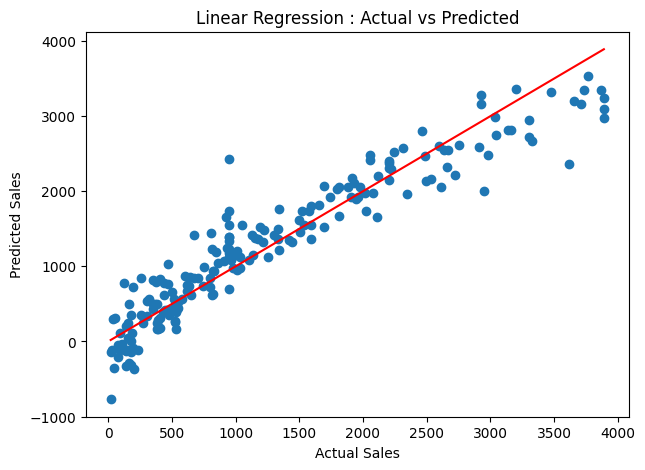

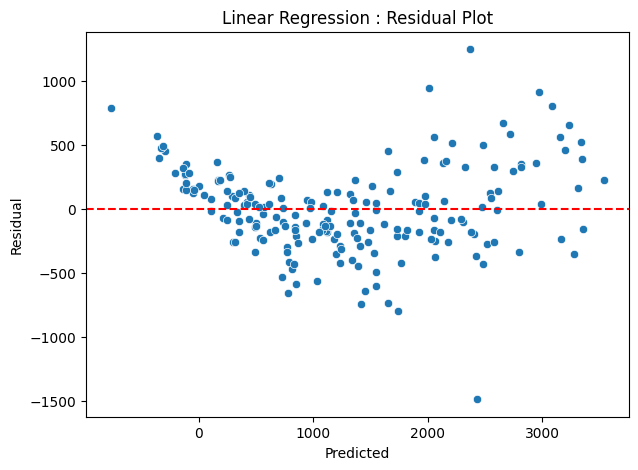

MAE : 255.41
MSE : 114653.43
RMSE : 338.61
MAPE : 0.7992
R2 Score : 0.8947
Adjusted R2 : 0.5725


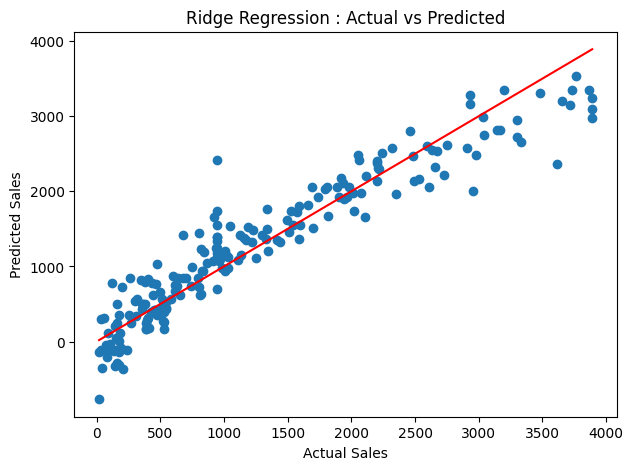

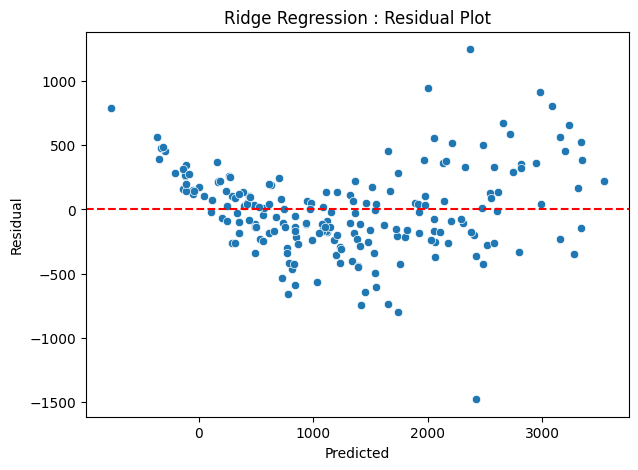

MAE : 255.43
MSE : 114737.33
RMSE : 338.73
MAPE : 0.7998
R2 Score : 0.8947
Adjusted R2 : 0.5722


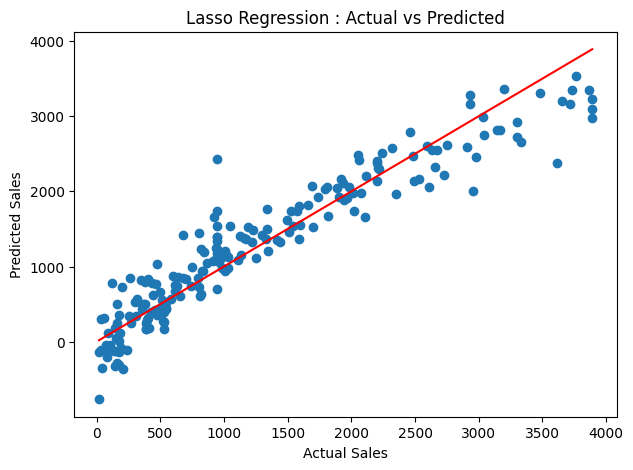

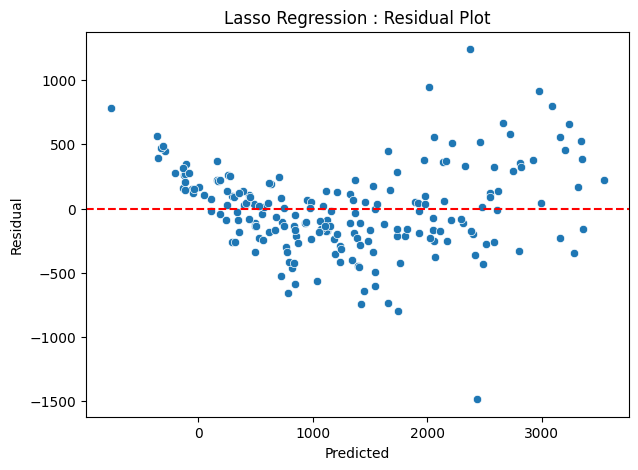

MAE : 250.54
MSE : 112025.01
RMSE : 334.7
MAPE : 0.7471
R2 Score : 0.8971
Adjusted R2 : 0.5823


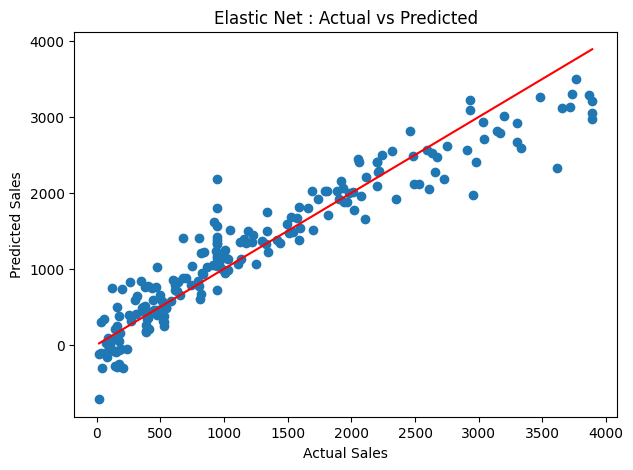

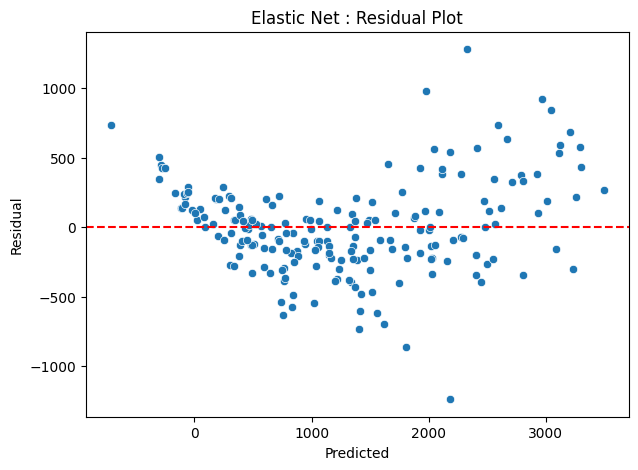

In [121]:
results = []

for model_name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    rmse=np.sqrt(mse)
    mape=mean_absolute_percentage_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    adjr2=adjusted_r2(r2, len(y_test), x_test.shape[1])

    results.append([model_name, mae, mse, rmse, mape, r2, adjr2])
    print("MAE :",round(mae,2))
    print("MSE :",round(mse,2))
    print("RMSE :",round(rmse,2))
    print("MAPE :",round(mape,4))
    print("R2 Score :",round(r2,4))
    print("Adjusted R2 :",round(adjr2,4))

    plt.figure(figsize=(7,5))
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()], color='red')
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.title(f"{model_name} : Actual vs Predicted")
    plt.show()

    residual=y_test-y_pred
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=y_pred, y=residual)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"{model_name} : Residual Plot")
    plt.show()

In [122]:
comparison=pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "MAPE", "R2 Score", "Adjusted R2"])

comparison=comparison.sort_values(by="R2 Score", ascending=False)
display(comparison)

,Model,MAE,MSE,RMSE,MAPE,R2 Score,Adjusted R2
3,Elastic Net,250.537261,112025.014841,334.701382,0.747121,0.897150,0.582301
1,Ridge Regression,255.412681,114653.432603,338.605128,0.799205,0.894736,0.572501
2,Lasso Regression,255.432407,114737.330388,338.728993,0.799796,0.894659,0.572188
0,Linear Regression,255.697501,114816.046503,338.845166,0.800988,0.894587,0.571895


In [123]:
best_model_name=comparison.iloc[0]["Model"]
print("\nBest Model :",best_model_name)


Best Model : Elastic Net


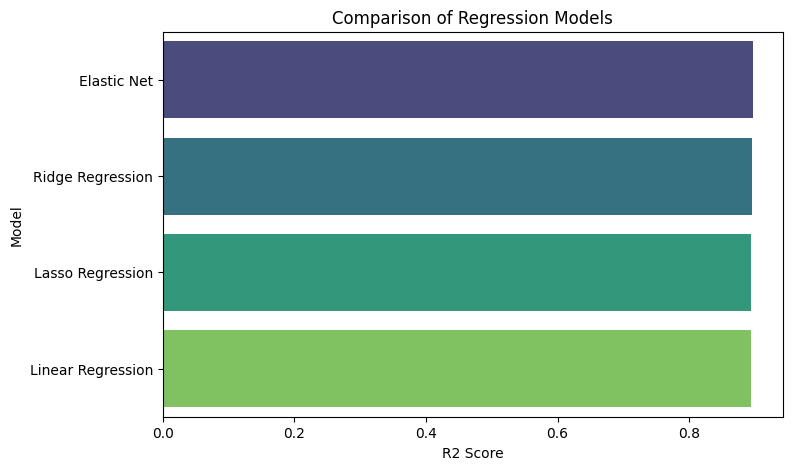

In [124]:
plt.figure(figsize=(8,5))

sns.barplot(data=comparison, x="R2 Score", y="Model", palette="viridis")
plt.title("Comparison of Regression Models")
plt.show()

In [125]:
def adjusted_r2(r2,n,p):
    return 1-((1-r2)*(n-1)/(n-p-1))

In [126]:
print("\nGRID SEARCH CV")

grid_models={"Ridge":(Ridge(), {"alpha":[0.01,0.1,1,10,50,100]}),
             "Lasso":(Lasso(), {"alpha":[0.0001,0.001,0.01,0.1,1]}),
             "ElasticNet":(ElasticNet(), {"alpha":[0.001,0.01,0.1,1]})}

grid_results=[]
best_grid_model=None
best_score=-999
for name,(model,param) in grid_models.items():
    grid=GridSearchCV(estimator=model, param_grid=param, cv=5, scoring="r2", n_jobs=-1)
    grid.fit(x_train,y_train)
    prediction=grid.predict(x_test)
    mae=mean_absolute_error(y_test,prediction)
    mse=mean_squared_error(y_test,prediction)
    rmse=np.sqrt(mse)
    mape=mean_absolute_percentage_error(y_test,prediction)
    r2=r2_score(y_test,prediction)
    adj=adjusted_r2(r2, len(y_test), x_test.shape[1])
    print("Best Parameters :",grid.best_params_)
    print("Best CV Score :",grid.best_score_)
    print("Test R² :",r2)
    grid_results.append([name, grid.best_params_, mae, mse, rmse, mape, r2, adj])
    if r2>best_score:
        best_score=r2
        best_grid_model=grid


GRID SEARCH CV
Best Parameters : {'alpha': 50}
Best CV Score : 0.8590625587422508
Test R² : 0.8969153979889712
Best Parameters : {'alpha': 1}
Best CV Score : 0.8578928360959118
Test R² : 0.8967634976867068
Best Parameters : {'alpha': 0.1}
Best CV Score : 0.8581386191122636
Test R² : 0.8971495579362698


In [127]:
random_model=RandomizedSearchCV(estimator=ElasticNet(), param_distributions={"alpha":np.linspace(0.0001,5,100),
        "l1_ratio":np.linspace(0.1,1,20)}, n_iter=30, cv=5, random_state=42, scoring="r2", n_jobs=-1)
random_model.fit(x_train,y_train)
random_prediction=random_model.predict(x_test)
random_mae=mean_absolute_error(y_test,random_prediction)
random_mse=mean_squared_error(y_test,random_prediction)
random_rmse=np.sqrt(random_mse)
random_mape=mean_absolute_percentage_error(y_test,random_prediction)
random_r2=r2_score(y_test,random_prediction)
random_adj=adjusted_r2(random_r2, len(y_test), x_test.shape[1])
print("\nBest Parameters")
print(random_model.best_params_)
print("\nBest CV Score")
print(random_model.best_score_)


Best Parameters
{'l1_ratio': np.float64(0.9526315789473684), 'alpha': np.float64(2.7778222222222224)}

Best CV Score
0.8667688385121834


In [128]:
grid_table=pd.DataFrame(grid_results, columns=["Model", "Best Parameters", "MAE", "MSE", "RMSE", "MAPE", "R² Score", "Adjusted R²"])
print("\nGRID SEARCH RESULTS")
display(grid_table)


GRID SEARCH RESULTS


,Model,Best Parameters,MAE,MSE,RMSE,MAPE,R² Score,Adjusted R²
0,Ridge,{'alpha': 50},250.419188,112280.062569,335.082173,0.736381,0.896915,0.581350
1,Lasso,{'alpha': 1},252.341605,112445.512841,335.328962,0.802046,0.896763,0.580733
2,ElasticNet,{'alpha': 0.1},250.537261,112025.014841,334.701382,0.747121,0.897150,0.582301


In [129]:
random_table=pd.DataFrame({"Model":["ElasticNet (Random Search)"],
                           "Best Parameters":[random_model.best_params_],
                           "MAE":[random_mae],
                           "MSE":[random_mse],
                           "RMSE":[random_rmse],
                           "MAPE":[random_mape],
                           "R² Score":[random_r2],
                           "Adjusted R²":[random_adj]})

print("\nRANDOM SEARCH RESULT")
display(random_table)


RANDOM SEARCH RESULT


,Model,Best Parameters,MAE,MSE,RMSE,MAPE,R² Score,Adjusted R²
0,ElasticNet (Random Search),"{'l1_ratio': 0.9526315789473684, 'alpha': 2.77...",244.350735,111617.80557,334.09251,0.679744,0.897523,0.58382


In [130]:
if random_r2>best_score:
    final_model=random_model.best_estimator_
    final_name="ElasticNet (Randomized Search)"
else:
    final_model=best_grid_model.best_estimator_
    final_name=grid_table.sort_values("R² Score", ascending=False).iloc[0]["Model"]

print(final_name)
print("\nBest Model Parameters")
print(final_model)

ElasticNet (Randomized Search)

Best Model Parameters
ElasticNet(alpha=np.float64(2.7778222222222224),
           l1_ratio=np.float64(0.9526315789473684))


In [131]:
y_pred = final_model.predict(x_test)

prediction_df = pd.DataFrame({"Actual Sales":y_test, "Predicted Sales":y_pred, "Residual":y_test-y_pred})
prediction_df.reset_index(drop=True,inplace=True)
print("\nFirst 20 Predictions")
display(prediction_df.head(20))


First 20 Predictions


,Actual Sales,Predicted Sales,Residual
0,543.210,530.316650,12.893350
1,98.960,14.891871,84.068129
2,1331.730,1345.974553,-14.244553
3,185.100,190.432907,-5.332907
4,515.570,564.655915,-49.085915
5,389.020,221.815984,167.204016
6,2668.860,2424.805591,244.054409
7,945.435,1133.306367,-187.871367
8,945.435,1081.401930,-135.966930
9,945.435,1335.987203,-390.552203


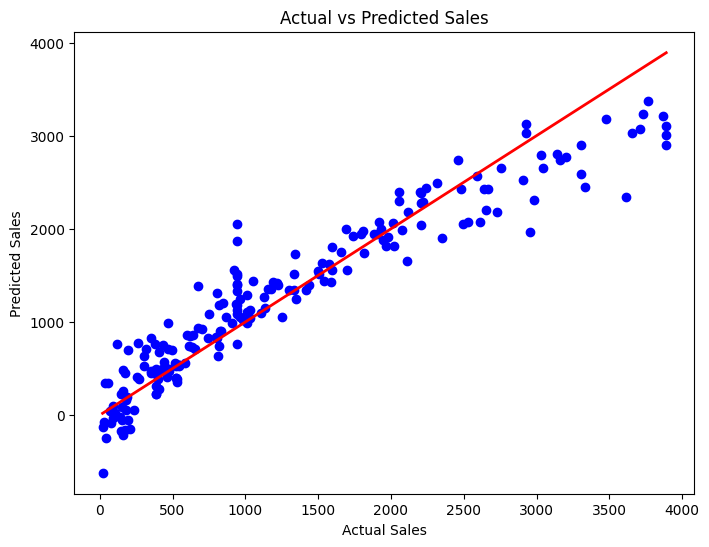

In [132]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

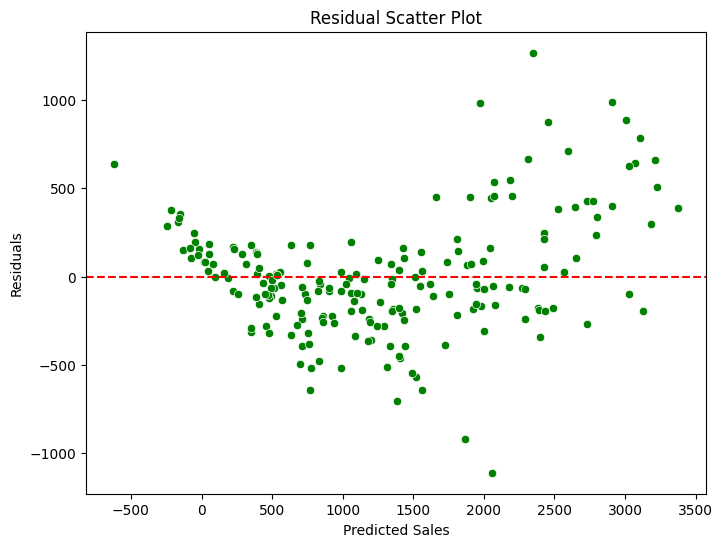

In [133]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals, color="green")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Scatter Plot")
plt.show()

In [134]:
joblib.dump(final_model, "Retail_Sales_Prediction_Model.joblib")

['Retail_Sales_Prediction_Model.joblib']

In [135]:
with open("Retail_Sales_Prediction_Model.pkl", "wb") as file:
    pickle.dump( final_model, file)

In [136]:
print("""
1. Sales increase significantly with higher Quantity purchased.
2. Products having higher Unit Price generally generate more revenue.
3. Very high discounts tend to reduce Profit Margin.
4. Loyalty customers contribute consistent and repeat sales.
5. Certain stores outperform others in total sales.
6. Regional demand varies considerably across locations.
7. Payment methods indicate customer purchase preferences.
8. Product Category is one of the strongest predictors of Sales.
9. Feature Engineering improved the predictive capability of the model.
10. Hyperparameter tuning improved model performance over the default settings.
""")


1. Sales increase significantly with higher Quantity purchased.
2. Products having higher Unit Price generally generate more revenue.
3. Very high discounts tend to reduce Profit Margin.
4. Loyalty customers contribute consistent and repeat sales.
5. Certain stores outperform others in total sales.
6. Regional demand varies considerably across locations.
7. Payment methods indicate customer purchase preferences.
8. Product Category is one of the strongest predictors of Sales.
9. Feature Engineering improved the predictive capability of the model.
10. Hyperparameter tuning improved model performance over the default settings.

